## Matched filtering for tau



- test beam asymmetry error: convolve map with gaussian beam (known) -> add noise -> deconvolve and see the difference with the original singal, how well I can recover it. // convolve map with realistic beam  -> add noise ->  deconvolve with symmetrized beam (get the Cls from the beam map and use smoothing). How to add noise: we know that reasonably $\sigma_{N_1} = 20 \mu k \,\,1 arcmin$. We can then rescale it using the relation $\sigma_N\propto 1/\sqrt{N_{pix}}$ and get teh value for the pixel size of the map $\sigma_{N_{side}}^2= \sigma_{N_1}^2 (\Delta\Omega_{pix}/\Delta\Omega_{1})$. Then the noise map is an array of random variables with mean=0 and sigma=$\sigma_{N_{side}}$ with len=number of pixels (better method). Note: $\Delta\Omega$ should be in steradians. Another way is generating the angular power spectrum of the noise: $C_\ell^N = \sigma^2_N\Delta\Omega_{N}$. Cls noise should be of order $10^{-7}$ and constant, plus we should have. 
- recover tau with match filtering in both cases



-- modify CLASS/CAMB?



derive tau from the alms of the theoreticcal maps to see if it goes to zero


Test beam asymmetry error: convolve map with gaussian beam (known) -> add noise -> deconvolve and see the difference with the original singal, how well I can recover it. // convolve map with realistic beam  -> add noise ->  deconvolve with symmetrized beam (get the Cls from the beam map and use smoothing).


plot beam map from its Cls --> see symmetric beam


TO DO: 
- determine l_min, l_max for matched filtering: see when the ideal result becomes biased 
- need to repeat convolution without tau signal ??
- see if I manage to account for beam residuals in the map difference from 1) cross Cls 2) difference map
- Analytical computation to explain of: 1) Cls of difference map beam residuals 2) Cross Cls going to match filter, to see which systematics remain (some beam residuals should still correlate but not all)  ######divide difference map by Cls CMB --> shoudl find the auto power spectrum of beam errors
- Noise subtraction: try with matched filtering.  subtract noise from Cls_cross with matched filtering 
- later: think about a method to quantify the beam assimmetry and connect beam residuals to it --> would allow to estimate beam residuals and subtract them


I'm afraid that with deconvolution, beam residuals become correlated with CMB part, since both are divided by the same b_lm


ANALYSIS OF BEAM RESIDULAS

convolution: $b_{lm}^{true} a_{lm}$ --> deconvolution with symmetric beam ($b_{lm}^{true}=b_{l}^{symm}+\epsilon_{lm}$) : $\qquad a_{lm}^{dec}=\frac{b_{lm}^{true}}{b_{l}^{symm}} a_{lm} = (1+\epsilon_{lm})a_{lm}$




Deconvolved maps: 

$a_{lm}^0=(1+\epsilon_{lm}^0)a_{lm}^{CMB}$

$a_{lm}^1= [1-\tau_l+(1-\tau_l)\epsilon_{lm}^1]a_{lm}^{CMB}$ // $a_{lm}^1=(1+\epsilon_{lm}^1)a_{lm}^{CMB}$

$\delta a_{lm}^{dec}=[-\tau_l+\epsilon_{lm}^1-\epsilon_{lm}^0-\tau_l\epsilon_{lm}^1]a_{lm}^{CMB} $

- single out beam residuals at the alm level;

- derermine if beam residuals correlate (can I isolate $\langle\epsilon_{lm}^0 \epsilon_{lm}^1\rangle$ ?) - suntract $(1-\tau) a_{lm}^{CMB}$ --> $\langle (\epsilon_{lm}^0a_{lm}^{CMB})^* \epsilon_{lm}^1 a_{lm}^{CMB}\rangle = \langle(\epsilon_{lm}^0)^* \epsilon_{lm}^1\rangle C_l^{CMB} $  

- Isolate single beam residulas: $\langle (a_{lm}^{CMB})^* \epsilon_{lm}^0 a_{lm}^{CMB} \rangle = \langle \epsilon_{lm}^0 \rangle C_l^{CMB} $ (same for other map)

- Squared beam residulas $\langle (\epsilon_{lm}^0  a_{lm}^{CMB} )^* \epsilon_{lm}^0 a_{lm}^{CMB} \rangle = |\epsilon_{lm}^0|^2 C_l^{CMB} $ (same for other map)


EVENTUALLY: 
- repeat the analysis with correct tau damping on large scales (maybe computed from CAMB for that frequency)
- search for ways to do deconvolution (I think it's only possible from time-ordered data)
- modeling of asymmetric beams: read paper on bipolar spherical harmonic technique for Planck data: 1210.7318 - Revealing Non-circular beam effect in WMAP-7 CMB maps with BipoSH measures of Statistical Isotropy


DONE: 
- corrected the covariance matrix with difference of noise maps in E[tau] computation, checked that the noise difference is computed correctly. Does not change tau result by a lot and does not fix the bias we have.
- noiseless ideal case: cross-Cls change a lot, recover correct tau value. Doubt: I'm still using ClN but here it makes no sense
- found beam effects on Cls_diff (compare noiseless case realistic vs ideal)

NOTEBOOK CONTENT: 
- theoretical maps
- beams: cut below a certain threshold
- convolved maps 
- compute noise
- deconvolved maps 
- tau 

- Deconvolution and tau estimation with matched filtering for: 
    1) realistic beam + noise 
    2) realistic beam noiseless
    3) symmetrci beam + noise
    4) symmetric beam noiseless



In [1]:
# %matplotlib widget
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from astropy.io import fits

In [2]:
#### READ FILES ####
tau_th=1e-3


dir_="/home/evanetti/BEAMS/code_input/"

#### read original CMB maps
fcmb='convolved_maps/map0.fits'
map_cmb=hp.fitsfunc.read_map(dir_+fcmb, field=0)
fxi='convolved_maps/map_xi.fits'
map_xi=hp.fitsfunc.read_map(dir_+fxi, field=0)

#### read convolved CMB maps 
f0="convolved_maps/map0_convolved_map1024_fast_mpi.fits"
f1='convolved_maps/map_xi_convolved_map1024_fast_mpi.fits'
map0=hp.fitsfunc.read_map(dir_+f0, field=0) #30 GHz
map1=hp.fitsfunc.read_map(dir_+f1, field=0) #70 GHz

nside0=hp.get_nside(map0)
nside1=hp.get_nside(map1)
nside=min(nside0, nside1)
if nside0!=nside1: 
    print('WARNING: maps have different Nside!! Downgrading to lower resolution map: nside = ', nside)
    map0=hp.pixelfunc.ud_grade(map0, nside)
    map1=hp.pixelfunc.ud_grade(map1, nside)
print(f"Nside CMB maps: {nside0} (map0), {nside1} (map1) --> common Nside = {nside}")

#### read beam maps
f0beam='beams_030_2247339.fits'
f1beam='beams_070_2247339.fits'
beam0=hp.fitsfunc.read_map(dir_+f0beam, field=0) #30 GHz
beam1=hp.fitsfunc.read_map(dir_+f1beam, field=0) #70 GHz

nside_beam0=hp.get_nside(beam0)
nside_beam1=hp.get_nside(beam1)
print(f"Nside CMB maps: {nside_beam0} (beam0), {nside_beam1} (beam1)")

#get Cls from PLA: 
fnamePLA='COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt'  #read Cls from PLA - checked that this is lensed
lPLA, DlPLA = np.genfromtxt(dir_+fnamePLA, dtype="float", comments="#", usecols=(0,1), unpack=True)
normClPLA=lPLA*(lPLA+1)/(2*np.pi)
ClPLA=DlPLA/normClPLA

### lmax corresponding to nside: 
lmax = 3*nside-1
print('lmax corresponding to nside: ', lmax)

ll=np.arange(lmax+1)
normCl=ll*(ll+1)/(2*np.pi)  #normCl=1

Nside CMB maps: 1024 (map0), 1024 (map1) --> common Nside = 1024
Nside CMB maps: 1024 (beam0), 1024 (beam1)
lmax corresponding to nside:  3071


# Theoretical maps

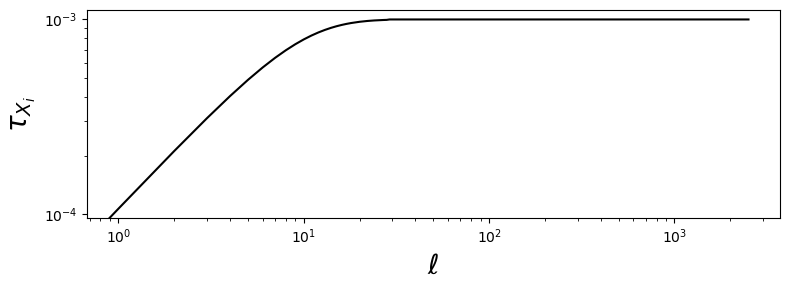

In [3]:
lcut=30

lPLA_= np.concatenate(([0, 1], lPLA))
ClPLA_ = np.concatenate(([0, 0], ClPLA))

y1 = np.linspace(0, 5, lcut-1)  # domain
yy1 = 1 - np.exp(-y1) 

y2 = np.linspace(0, 3, lcut-1)
yy2 = np.tanh(y2)

arr=np.concatenate((yy2,np.ones(len(lPLA_)-(lcut-1))))
tau_l=tau_th*arr


plt.figure(figsize=(8,3))
#plt.plot(l[:(lcut-1)], yy1)
#plt.plot(l[:(lcut-1)], yy2)
plt.loglog(lPLA_, tau_l, color='k')
plt.xlabel(r'$\ell$', fontsize=20)
plt.ylabel(r'$\tau_{X_i}$', fontsize=20)
plt.tight_layout()
plt.show()#'''

# theoretical blurred Cls --> checked that it damps peaks
Cl_xi_th=ClPLA_-2*tau_l*ClPLA_  



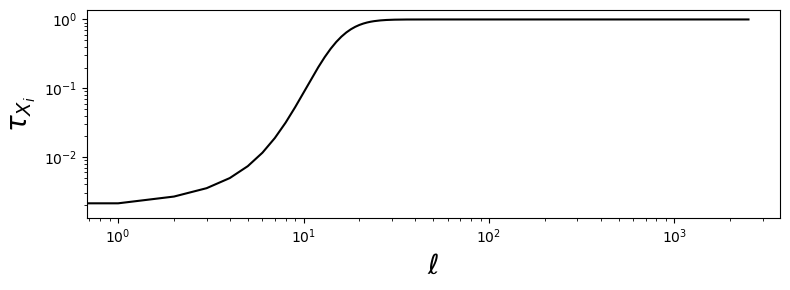

In [4]:
lcut=8
damping_orders=3
width_par=1.2 #increase for steeper damping
lPLA_= np.concatenate(([0, 1], lPLA))
ClPLA_ = np.concatenate(([0, 0], ClPLA))


def damping_function(x, lcut, damping_orders, width_par):
    """
    Smooth damping function that damps by `damping_orders` at low lPLA
    and has no damping at lcut.
    
    Uses a hyperbolic tangent transition for smoothness.
    
    Parameters:
    -----------
    lPLA : array-like
        The multipole values
    lcut : float
        The multipole value where damping becomes zero (default: 30)
    damping_orders : float
        Number of orders of magnitude to damp at low lPLA (default: 4)
    
    Returns:
    --------
    damping : array-like
        Damping factor (multiply ClPLA by this)
    """
    # Transition width parameter (controls smoothness)
    width = lcut / width_par
    
    # Smooth transition using tanh
    # Goes from 0 at low lPLA to 1 at lcut
    transition = 0.5 * (1 + np.tanh((x - lcut) / width))
    
    # Damping factor: 10^(-damping_orders) at low lPLA, 1 at high lPLA
    damping = 10**(-damping_orders * (1 - transition))
    
    return damping



damping_factor = damping_function(lPLA_, lcut, damping_orders, width_par)

tau2_l=tau_th*damping_factor

plt.figure(figsize=(8,3))
#plt.plot(l[:(lcut-1)], yy1)
#plt.plot(l[:(lcut-1)], yy2)
plt.plot(lPLA_, damping_factor, color='k')

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$\ell$', fontsize=20)
plt.ylabel(r'$\tau_{X_i}$', fontsize=20)
plt.tight_layout()
plt.show()#'''



In [5]:
## theoretical Cls with tau: 
ClPLA_xi=(1-2*tau_l[2:])*ClPLA
ClPLA_xi2=(1-2*tau2_l[2:])*ClPLA

In [6]:
# compute Cls of theoretical realizations
Cls_map_cmb=hp.anafast(map_cmb, lmax=lmax)
Cls_map_xi=hp.anafast(map_xi, lmax=lmax)
print('Nside=1024 Cls array length:', len(Cls_map_cmb), len(ll) )
mapdiff_th=map_xi-map_cmb
Cls_mapdiff_th=hp.anafast(mapdiff_th, lmax=lmax)

#compute Cls of convolved maps
Cls_map0=hp.anafast(map0, lmax=lmax)
Cls_map1=hp.anafast(map1, lmax=lmax)


Nside=1024 Cls array length: 3072 3072


<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:23: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:23: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_128914/3369393406.py:4: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(ll, Cls_map_cmb, color='black', ls='-', label='$C_\ell^0$')
/tmp/ipykernel_128914/3369393406.py:5: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(ll, Cls_map_xi, color='blue', ls='-', label='$C_\ell^{X_i}$')
/tmp/ipykernel_128914/3369393406.py:6: SyntaxWarning: invalid escape sequence '\e'
  p

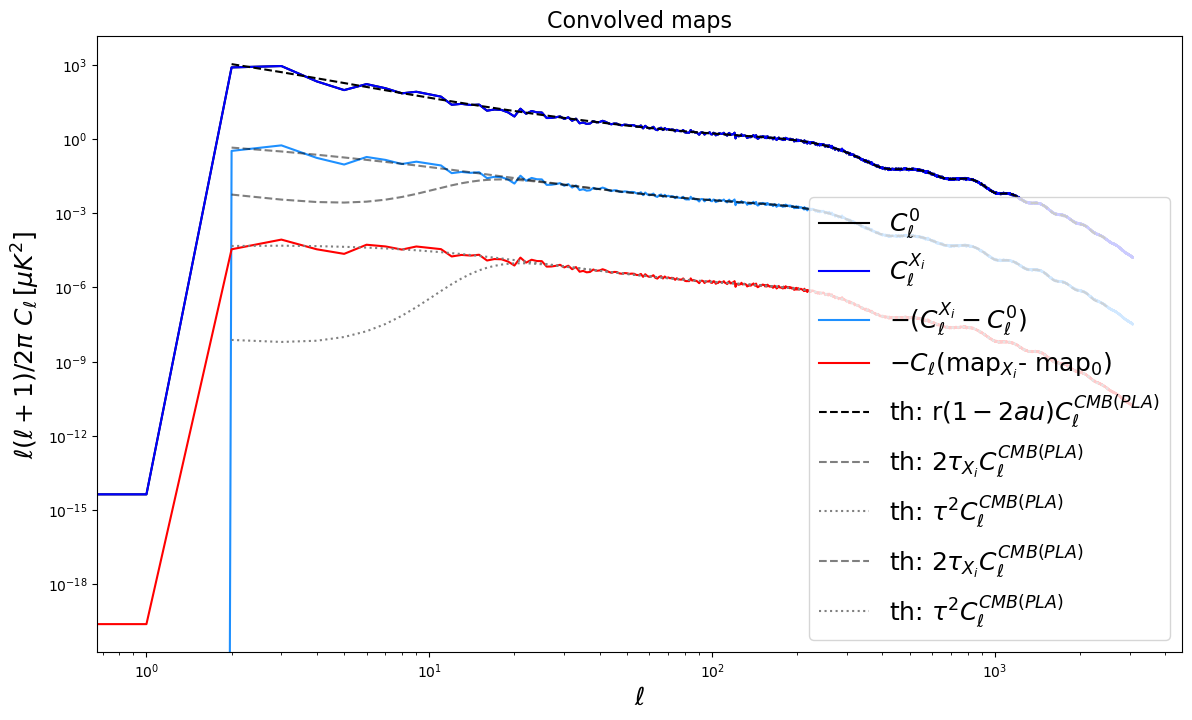

In [7]:
### ### Check Cls of original maps: compare to theory
#Cls from maps
plt.figure(figsize=(14,8))
plt.plot(ll, Cls_map_cmb, color='black', ls='-', label='$C_\ell^0$')
plt.plot(ll, Cls_map_xi, color='blue', ls='-', label='$C_\ell^{X_i}$')
plt.plot(ll, -(Cls_map_xi-Cls_map_cmb), color='dodgerblue', ls='-', label='$-(C_\ell^{X_i}-C_\ell^0) $')
plt.plot(ll, Cls_mapdiff_th, color='red', ls='-', label='$-C_\ell$(map$_{X_i}$- map$_0$)')

#theoretical Cls - corresponding to damping used for maps
plt.plot(lPLA, (1-2*tau_l[2:])*ClPLA,color='black', ls='--', label='th: r$(1-2\tau)C_\ell^{CMB(PLA)}$')
plt.plot(lPLA, 2*tau_l[2:]*ClPLA,color='black', alpha=0.5,  ls='--', label=r'th: $2\tau_{X_i}C_\ell^{CMB(PLA)}$')
plt.plot(lPLA, tau_l[2:]*tau_l[2:]*ClPLA,color='gray', ls=':', label=r'th: $\tau^2 C_\ell^{CMB(PLA)}$')


#theoretical Cls - NEW tau damping
plt.plot(lPLA, 2*tau2_l[2:]*ClPLA,color='black', alpha=0.5,  ls='--', label=r'th: $2\tau_{X_i}C_\ell^{CMB(PLA)}$')
plt.plot(lPLA, tau2_l[2:]*tau2_l[2:]*ClPLA,color='gray', ls=':', label=r'th: $\tau^2 C_\ell^{CMB(PLA)}$')


plt.xscale('log')
plt.yscale('log')
#plt.ylim(1e-5, 4e4)
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$\ell(\ell+1)/2\pi\,\,C_\ell\,[\mu K^2]$', fontsize=18)
plt.title('Convolved maps', fontsize=16)
plt.legend(fontsize=18, loc='lower right')
plt.show()
### check that the difference between alms is correct
#alm_cmb=hp.map2alm(map_cmb, lmax=lmax)
#alm_xi=hp.map2alm(map_xi, lmax=lmax)
#alm_diff=alm_xi-alm_cmb

<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_128914/3408782464.py:21: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$', fontsize=18)


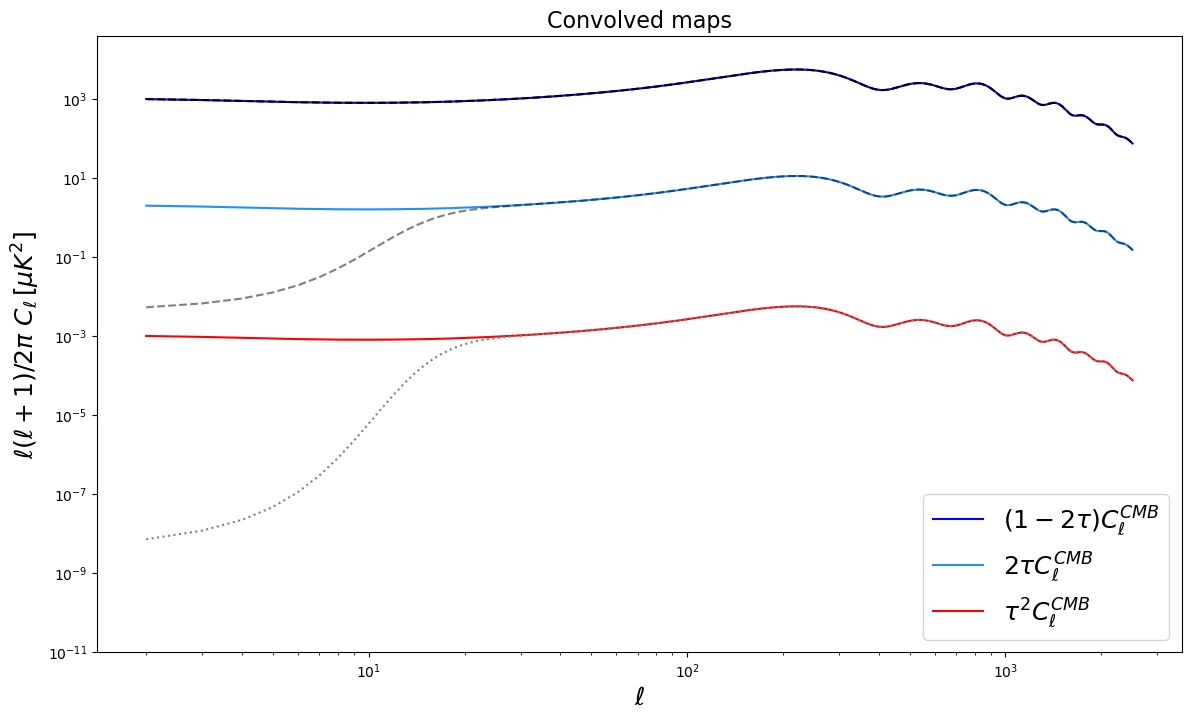

In [8]:
### Check Cls of original maps: compare to theory

#Cls from maps
plt.figure(figsize=(14,8))

#theoretical Cls - corresponding to damping used for maps
plt.plot(lPLA, normClPLA*(1-2*tau_th)*ClPLA, color='blue', ls='-', label=r'$(1-2\tau)C_\ell^{CMB}$')
plt.plot(lPLA, normClPLA*2*tau_th*ClPLA, color='dodgerblue', ls='-', label=r'$2\tau C_\ell^{CMB} $')
plt.plot(lPLA, normClPLA*tau_th*tau_th*ClPLA, color='red', ls='-', label=r'$\tau^2 C_\ell^{CMB}$')


#theoretical Cls - NEW tau damping
plt.plot(lPLA, normClPLA*(1-2*tau2_l[2:])*ClPLA,color='black', ls='--')
plt.plot(lPLA, normClPLA*2*tau2_l[2:]*ClPLA,color='black', alpha=0.5,  ls='--')
plt.plot(lPLA, normClPLA*tau2_l[2:]*tau2_l[2:]*ClPLA,color='gray', ls=':')


plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-11, 4e4)
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$\ell(\ell+1)/2\pi\,\,C_\ell\,[\mu K^2]$', fontsize=18)
plt.title('Convolved maps', fontsize=16)
plt.legend(fontsize=18, loc='lower right')
plt.show()

# Beams

In [9]:
#### Normalize beams (in steradians)
def normalizebeam(beam_map): 
    nside_beam=hp.get_nside(beam_map)
    pixArea_beam = hp.nside2pixarea(nside_beam) # pixel area in rad²

    norm_beam=np.sum(beam_map)*pixArea_beam
    beam_map_normalized=beam_map/norm_beam

    return beam_map_normalized

pixArea_rad = hp.nside2pixarea(nside_beam0)
print('initial beam normalization = ', np.sum(beam0)*pixArea_rad, np.sum(beam1)*pixArea_rad)

beam0_norm=normalizebeam(beam0)
beam1_norm=normalizebeam(beam1)

pixArea_rad = hp.nside2pixarea(nside_beam0)
print('normalized beam = ', np.sum(beam0_norm)*pixArea_rad, np.sum(beam1_norm)*pixArea_rad)
#'''

initial beam normalization =  0.9902673022155959 0.9910121966948694
normalized beam =  0.9999999284490205 0.9999999284490205


<Figure size 800x800 with 0 Axes>

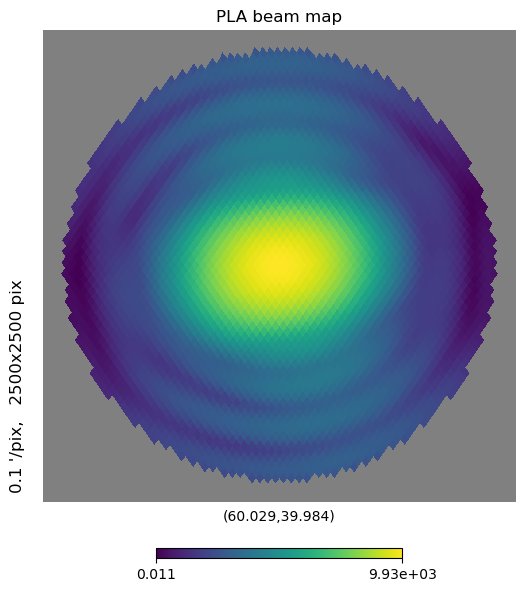

<Figure size 800x800 with 0 Axes>

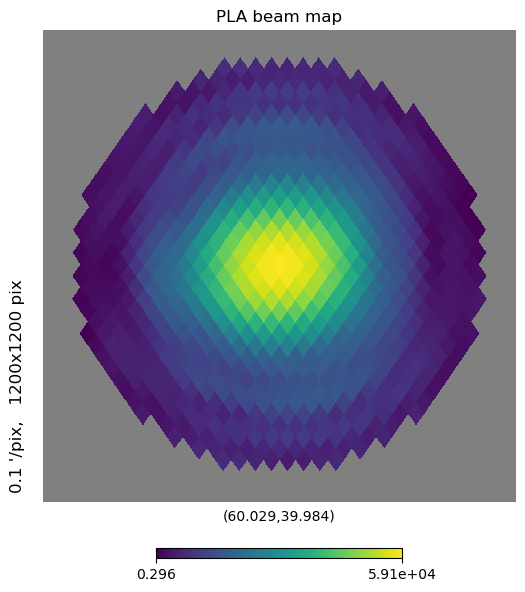

In [10]:
cpix=2247339
angc=hp.pixelfunc.pix2ang(nside, ipix=cpix, lonlat=True) #reurns phi, theta(lat)

import os

fig=plt.figure(figsize=(8,8))
map_beam_masked = np.where(beam0_norm==0, hp.UNSEEN, beam0_norm)
hp.visufunc.gnomview(map_beam_masked, rot=[angc[0], angc[1]], reso=0.1, xsize=2500, norm='log', title='PLA beam map', return_projected_map=True )
plt.savefig(os.path.expanduser('~/beam30.pdf'), format='pdf', bbox_inches='tight')
plt.show()



fig=plt.figure(figsize=(8,8))
map_beam_masked2 = np.where(beam1_norm==0, hp.UNSEEN, beam1_norm)
hp.visufunc.gnomview(map_beam_masked2, rot=[angc[0], angc[1]], reso=0.1, xsize=1200, norm='log', title='PLA beam map', return_projected_map=True )
plt.savefig(os.path.expanduser('~/beam70.pdf'), format='pdf', bbox_inches='tight')
plt.show()



In [11]:
#### Beam Cls: on large scales Cls should be = 1 (check also in convolution code)
Cls_beam0=hp.anafast(beam0_norm)*4*np.pi  # symmetrized beams
Cls_beam1=hp.anafast(beam1_norm)*4*np.pi

print('check that beam Cls are =1 on large scales')
print(f'                l={ll[0]}           l={ll[5]}               l={ll[10]}')
print('beam0: ', Cls_beam0[0], Cls_beam0[5], Cls_beam0[10] )
print('beam1: ', Cls_beam1[0], Cls_beam1[5], Cls_beam1[10] )

check that beam Cls are =1 on large scales
                l=0           l=5               l=10
beam0:  0.9999997726858023 0.9995110826338863 0.9982091972820877
beam1:  0.9999998235745321 0.9999160026227976 0.999692519519348


In [12]:
### cut high multipoles
threshold=1e-3

idx_lmax_cut0 = np.where(Cls_beam0 < threshold)[0][0]
lmax_cut0 = ll[idx_lmax_cut0]

idx_lmax_cut1 = np.where(Cls_beam1 < threshold)[0][0]
lmax_cut1 = ll[idx_lmax_cut1]

Cls_beam0_cut=Cls_beam0[:lmax_cut0]
Cls_beam1_cut=Cls_beam1[:lmax_cut1]
print(f"beam0: lmax_cut = {lmax_cut0}   Cl(l={ll[lmax_cut0]})={Cls_beam0[lmax_cut0]:.7f}")
print(f"beam1: lmax_cut = {lmax_cut1}   Cl(l={ll[lmax_cut1]})={Cls_beam1[lmax_cut1]:.7f}    Cl(l={ll[lmax_cut0]})={Cls_beam1[lmax_cut0]:.7f}")

ll_cut=ll[:lmax_cut0]
normCl_cut=normCl[:lmax_cut0]

beam0: lmax_cut = 669   Cl(l=669)=0.0009929
beam1: lmax_cut = 1619   Cl(l=1619)=0.0009953    Cl(l=669)=0.3006680


<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:17: SyntaxWarning: invalid escape sequence '\e'
<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:17: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_128914/2284391322.py:14: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$', fontsize=18)
/tmp/ipykernel_128914/2284391322.py:17: SyntaxWarning: invalid escape sequence '\e'
  plt.title('Beam Cls, $\ell_{cut}=$'+str(lmax_cut0), fontsize=15)


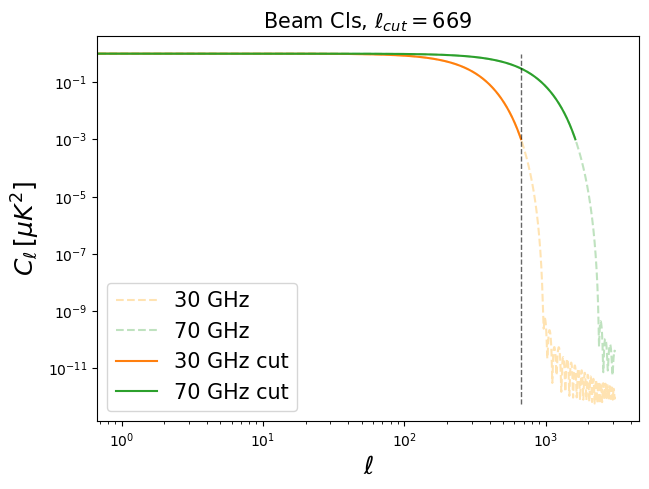

In [13]:
### plot beam Cls ###
plt.figure(figsize=(7,5))
plt.plot(ll, Cls_beam0, color='orange', ls='--', alpha=0.3, label='30 GHz')
plt.plot(ll, Cls_beam1, color='tab:green', ls='--', alpha=0.3, label='70 GHz')

plt.plot(ll[:lmax_cut0], Cls_beam0_cut, color='tab:orange', ls='-', label='30 GHz cut')
plt.plot(ll[:lmax_cut1], Cls_beam1_cut, color='tab:green', ls='-', label='70 GHz cut')

plt.vlines(lmax_cut0, np.min(Cls_beam0), np.max(Cls_beam0), color='black', alpha=0.6, ls='--', lw=1)


plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
plt.legend(fontsize=15)
plt.title('Beam Cls, $\ell_{cut}=$'+str(lmax_cut0), fontsize=15)
plt.show()

# Convolved maps

Expected: Cls of the convolved maps nearly coincide on large scales (since they are from the same realization), samped around the beam scale.

In [14]:
# CONVOLVE with symmetric beams
map0symm=hp.sphtfunc.smoothing(map_cmb, beam_window=np.sqrt(Cls_beam0_cut), lmax=lmax_cut0-1 )
map1symm=hp.sphtfunc.smoothing(map_xi, beam_window=np.sqrt(Cls_beam1_cut), lmax=lmax_cut0-1 )

Cls_map0symm=hp.anafast(map0symm, lmax=lmax_cut0-1)
Cls_map1symm=hp.anafast(map1symm, lmax=lmax_cut0-1)

<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_128914/1782261405.py:11: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$', fontsize=18)


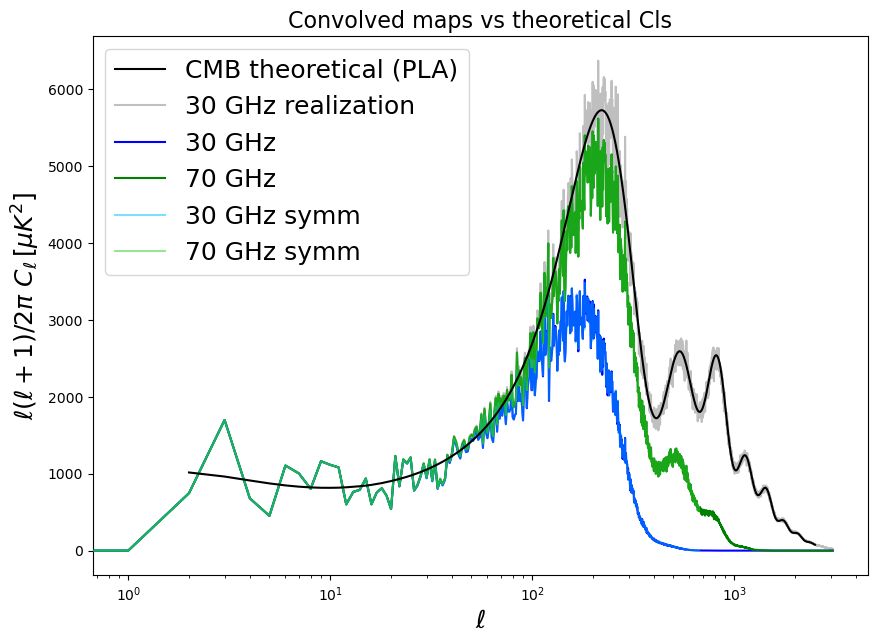

In [15]:
## PLOT convolved Cls
plt.figure(figsize=(10,7))
plt.plot(lPLA, normClPLA*ClPLA,color='black', ls='-', label='CMB theoretical (PLA)',zorder=10)
plt.plot(ll, normCl*Cls_map_cmb, color='gray',alpha=0.5, ls='-', label='30 GHz realization')
plt.plot(ll, normCl*Cls_map0, color='blue', ls='-', label='30 GHz') # realistic convolution
plt.plot(ll, normCl*Cls_map1, color='green', ls='-', label='70 GHz')
plt.plot(ll_cut, normCl_cut*Cls_map0symm, color='deepskyblue', alpha=0.5, ls='-', label='30 GHz symm', zorder=5)
plt.plot(ll_cut, normCl_cut*Cls_map1symm, color='limegreen', alpha=0.5, ls='-', label='70 GHz symm', zorder=6)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$\ell(\ell+1)/2\pi\,\,C_\ell\,[\mu K^2]$', fontsize=18)
plt.title('Convolved maps vs theoretical Cls', fontsize=16)
plt.legend(fontsize=18)
plt.show()

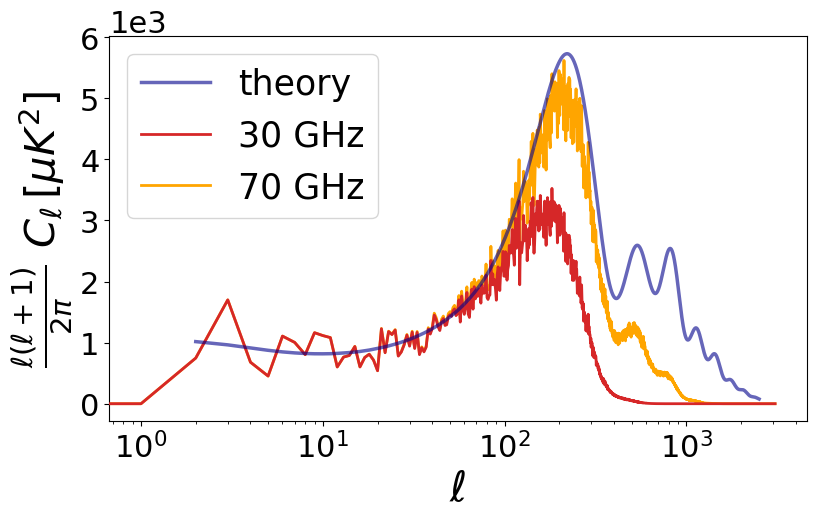

In [16]:
## PLOT convolved Cls
plt.figure(figsize=(9,5))
plt.plot(lPLA, normClPLA*ClPLA,color='darkblue', ls='-', alpha=0.6, lw=2.5, label='theory',zorder=10)
plt.plot(ll, normCl*Cls_map0, color='tab:red', ls='-', label='30 GHz', zorder=3, lw=2) # realistic convolution
plt.plot(ll, normCl*Cls_map1, color='orange', ls='-', label='70 GHz', lw=2)

plt.xscale('log')
#plt.yscale('log')
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.xlabel(r'$\ell$', fontsize=30)
plt.ylabel(r'$\frac{\ell(\ell+1)}{2\pi}\,\,C_\ell\,[\mu K^2]$', fontsize=30) 


plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0)) 
plt.gca().yaxis.get_offset_text().set_fontsize(22)


plt.legend(fontsize=25, loc='upper left')

plt.savefig('Conv_maps.png',dpi=300, bbox_inches='tight',  format='png')
plt.show()

In [17]:
def plot_diff(Cl1_list, Cl2_list, cut_min, cut_max, ax_names, leg_names, colors): 

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14,6), constrained_layout=True )   

    ll_plot=np.arange(len(Cl1_list[0])+1)

    yname1 = rf'$C_\ell^{{{ax_names[1]}}} - C_\ell^{{{ax_names[0]}}}$'
    yname2 = rf'$\left(C_\ell^{{{ax_names[1]}}} - C_\ell^{{{ax_names[0]}}}\right) / C_\ell^{{{ax_names[0]}}}$'


    # difference plot
    for ax in axes[0, :]:
        ax.set_ylabel(yname1, fontsize=18)
        ax.set_title('Difference', fontsize=16)
        for j in range(len(Cl1_list)):
            diff_plot=Cl2_list[j][cut_min:cut_max]-Cl1_list[j][cut_min:cut_max]
            ax.plot(ll_plot[cut_min:cut_max], diff_plot, color=colors[j] , label=leg_names[j])  #difference
            ax.legend(fontsize=15)

    # relative difference plot
    for ax in axes[1, :]:
        ax.set_ylabel(yname2, fontsize=18)
        ax.set_title('Relative difference', fontsize=16)
        for j in range(len(Cl1_list)):
            rel_diff_plot=(Cl2_list[j][cut_min:cut_max]-Cl1_list[j][cut_min:cut_max])/Cl1_list[j][cut_min:cut_max]
            ax.plot(ll_plot[cut_min:cut_max], rel_diff_plot, color=colors[j] , label=leg_names[j] )  #relative difference
            ax.legend(fontsize=15)


    fig.supxlabel(r'$\ell$',  fontsize=18)

    for ax in axes[:, 0]:
        ax.set_xscale('linear')
        ax.set_yscale('linear')

    for ax in axes[:, 1]:
        ax.set_xscale('log')
        ax.set_yscale('symlog', linthresh=1e-4)
        ax.hlines(0, ll_plot[cut_min], ll_plot[cut_max], color='black', linestyle='--')




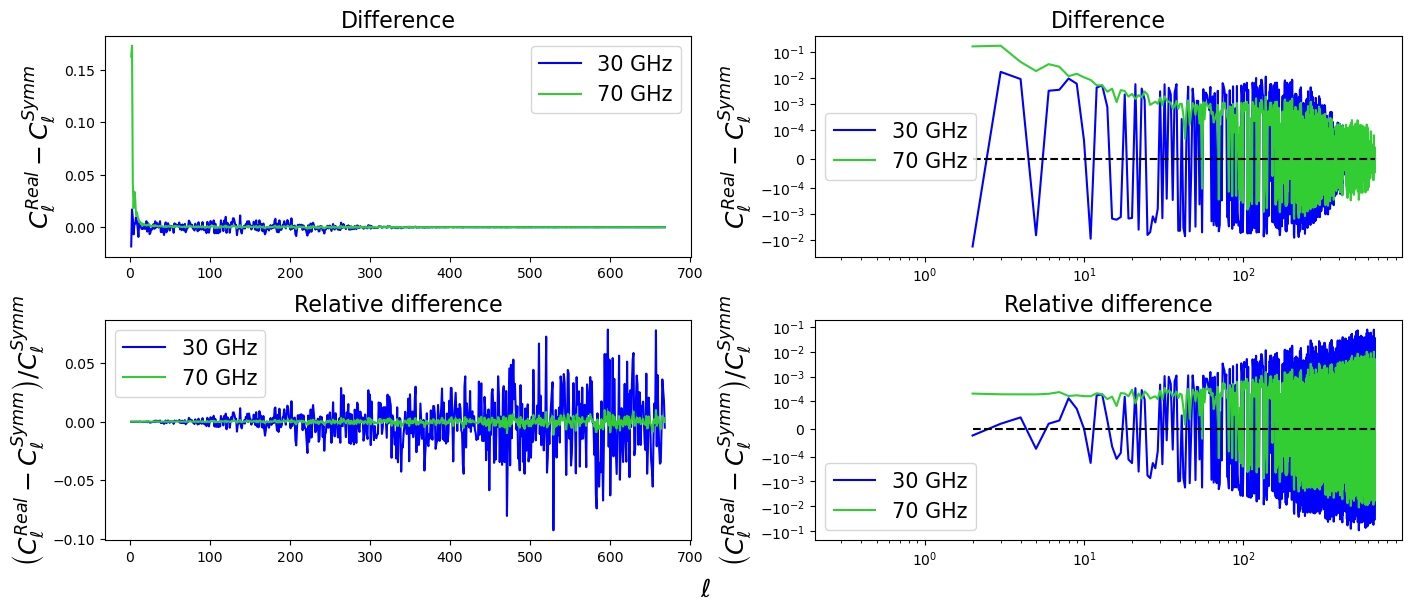

In [18]:
### Difference: Cls of map convolved with realistic beam vs symmetric beam (not deconvolved yet)
lab_names=['Symm', 'Real'] #'- 30 GHz - realistic beam vs symmetric beam'
leg_names=['30 GHz', '70 GHz']
colors=['blue', 'limegreen']
plot_diff([Cls_map0symm, Cls_map1symm], [Cls_map0, Cls_map1], 2, lmax_cut0, lab_names, leg_names, colors )

# Adding Noise:

<font color="red">Doubt: sigma fitted from noise Cls is always around 1% below the theoretical value (seen by changes a few realizations)</font>

2 methods to generate a white nosie map: 

a) map = array with len $=N_{pix}$ of random variables with mean $=0$, variance $=\sigma_{pix}^2$ [IN USE]

b) flat angular power spectrum $C_\ell^N = \sigma_{pix}^2 \Delta\Omega_{pix}$, where $\Delta\Omega_{pix}$ is the pixel area in steradians (rad²). get map with hp.synfast. Note: this method underestimates the variance because $\sigma^2=\sum_\ell \frac{2\ell+1}{4\pi}C_\ell $ with the sum truncated at $\ell_{max}$ numerically, while it should go to $\ell=\infty$

$\sigma_{pix}$ is the variance od the noise inside the pixel area $\Delta\Omega_{\rm{pix}}$<br>
the variance inside a certain area scales as $\sigma\propto\frac{1}{\sqrt{N}}$, where $N$ is the number of hits in the area (less noise for a bigger area)<br>
If we assume uniform scanning strategy, the number of hits is directly porportional to the area: $ N\propto \Delta\Omega_{pix} = \frac{4\pi}{N_{\rm{pix}}}= \frac{4\pi}{12 N_{\rm{side}}^2}\quad\longrightarrow\quad \sigma_{pix}\propto\frac{1}{\sqrt{\Delta\Omega_{pix} }}\propto\sqrt{N_{pix}}\propto N_{\rm{side}} $<br>
2 methods to compute $\sigma_{pix}$: 
1) from a known variance connected to a certain area: for  CMB experiment, reasonably $\sigma_*=20\,\,\mu \rm{K}$ for an area of $\Delta\Omega_* = 1$ arcmin²  = $(\frac{1}{60}^\circ)^2$ = $(\frac{1}{60}\,\frac{\pi}{180})^2$ steradians (rad²)  $\longrightarrow \sigma_{pix} = \sigma_{*}\sqrt{\frac{\Delta\Omega_*}{\Delta\Omega_{\rm{pix}}}}$  
2) Get $\sigma[\mu\rm{K\,\,deg} ]$ form Tab.2 of paper 1907.11642 and convert it with $\sigma_{\rm{pix}}[\mu\rm{K}]=\frac{\sigma[\mu\rm{K\,\,deg}]}{\sqrt{\Delta\Omega_{\rm{pix}}}}$ [IN USE]
<p style="color:blue;"> Check: units of $\sigma$ in Tab.2 and of my CMB maps need to match. Check if they are muK in Rayleigh Jeans or CMB units.</p> 

In [19]:
## NOISE 1) noise computed from 20 muK at 1 arcmin
'''
sigma_1arcmin=20 #in muK (like the map) -- corresponding to 1 arcmin
Area1=1*(np.pi/180/60)**2  #1 square arcmin in steradians

pixArea=hp.nside2pixarea(nside, degrees=False) #area in square steradians (square radians)

sigma_pix=sigma_1arcmin*np.sqrt(Area1/pixArea) #in muK 
print('Nside = ', nside)
print(f'pixArea = {pixArea:.3e} steradians \t Area(1 armin²) = {Area1:.3e} steradians \t Area*/pixArea = {Area1/pixArea:.3f}')
print('pixArea larger than Area* --> sigma_pix should be smaller')
print(f'sigma_pix = {sigma_pix:.3f}\t sigma* = {sigma_1arcmin:.3f}')


### create noise map:
npix=hp.nside2npix(nside) # generate noise map

map0_n=np.random.normal(loc=0.0, scale=sigma_pix, size=npix) 
map_noise1=np.random.normal(loc=0.0, scale=sigma_pix, size=npix)

map0_n=map0+map0_n
map1_noisy=map1+map_noise1

print('\nCHECK that sigma*A is constant:', sigma_pix*np.sqrt(pixArea), sigma_1arcmin*np.sqrt(Area1), '--> OK')
var_noise0=np.var(map0_n)
var_noise1=np.var(map_noise1)

print(f'CHECK: sigma_pix from map variance = {(var_noise0)**0.5}, {(var_noise1)**0.5} --> OK')
'''

"\nsigma_1arcmin=20 #in muK (like the map) -- corresponding to 1 arcmin\nArea1=1*(np.pi/180/60)**2  #1 square arcmin in steradians\n\npixArea=hp.nside2pixarea(nside, degrees=False) #area in square steradians (square radians)\n\nsigma_pix=sigma_1arcmin*np.sqrt(Area1/pixArea) #in muK \nprint('Nside = ', nside)\nprint(f'pixArea = {pixArea:.3e} steradians \t Area(1 armin²) = {Area1:.3e} steradians \t Area*/pixArea = {Area1/pixArea:.3f}')\nprint('pixArea larger than Area* --> sigma_pix should be smaller')\nprint(f'sigma_pix = {sigma_pix:.3f}\t sigma* = {sigma_1arcmin:.3f}')\n\n\n### create noise map:\nnpix=hp.nside2npix(nside) # generate noise map\n\nmap0_n=np.random.normal(loc=0.0, scale=sigma_pix, size=npix) \nmap_noise1=np.random.normal(loc=0.0, scale=sigma_pix, size=npix)\n\nmap0_n=map0+map0_n\nmap1_noisy=map1+map_noise1\n\nprint('\nCHECK that sigma*A is constant:', sigma_pix*np.sqrt(pixArea), sigma_1arcmin*np.sqrt(Area1), '--> OK')\nvar_noise0=np.var(map0_n)\nvar_noise1=np.var(map_nois

In [61]:
#### NOISE 2) noise from paper, for different frequency channels
## Cls in PLA are in muK CMB 
nu=np.array([30,     44,     70,     100,    143,    217,    353,    545,    857])
sigma_mukdeg=np.array([2.45,   2.57,   3.08,   1.00,   0.333,  0.261,  0.198,  0.0855, 0.0319 ])  ##thermal noise data from Tab.2 of 1907.11642
#sigma_mukdeg=np.array([0.261,   2.57,   0.198,   1.00,   0.333,  0.261,  0.198,  0.0855, 0.0319 ])  ##thermal noise data from Tab.2 of 1907.11642

#in muK deg --> need to convert

pixArea_deg=hp.nside2pixarea(nside, degrees=True)
sigma_pix_muk=sigma_mukdeg/np.sqrt(pixArea_deg)
#print('sigma_pix(nu) = ', sigma_pix_muk)

sigma30=sigma_pix_muk[0]
sigma70=sigma_pix_muk[2]
print('sigma_pix(nu=30GHz) = ', sigma30)
print('sigma_pix(nu=70GHz) = ', sigma70)


### create noise maps:
npix=hp.nside2npix(nside) # generate noise map
map_noise0 = np.random.normal(loc=0.0, scale=sigma30, size=npix)
map_noise1 = np.random.normal(loc=0.0, scale=sigma70, size=npix)
map_noise10=map_noise1-map_noise0  


sigma_pix(nu=30GHz) =  42.78870074826918
sigma_pix(nu=70GHz) =  53.79150951210982


In [62]:
## ADD NOISE to maps: 
map0_n=map0+map_noise0 #realistic beam + noise
map1_n=map1+map_noise1

map0symm_n=map0symm+map_noise0 #symmetric beam + noise
map1symm_n=map1symm+map_noise1


In [63]:
#### CHECK: plot Cls noise ####
Cls_map_noise0=hp.anafast(map_noise0, lmax=lmax)
Cls_map_noise1=hp.anafast(map_noise1, lmax=lmax)
Cls_map_noise10=hp.anafast(map_noise10, lmax=lmax) ### needed for tau computation

Cls_map0_n=hp.anafast(map0_n, lmax=lmax)
Cls_map1_n=hp.anafast(map1_n, lmax=lmax)

Cls_map0symm_n=hp.anafast(map0symm_n, lmax=lmax)
Cls_map1symm_n=hp.anafast(map1symm_n, lmax=lmax)


In [64]:
### unit conversion: CMB - RJ
'''
import Tunit_conversion

# Example: Convert a Planck 143 GHz map from CMB to RJ temperature
mapinfo = {
    'frequency': 143.0,  # GHz
    'nside': 1024,       # HEALPix resolution
    'units': 'mKCMB'     # Input units
}

factor = Tunit_conversion.convert_to_mK(mapinfo)
print(f"To convert {mapinfo['frequency']:.0f} GHz CMB map of Nside {mapinfo['nside']:.0f} to mK: multiply by {factor:.3f}")

# map_mK_RJ = map_mKCMB * factor  # <--- apply this way
'''


'\nimport Tunit_conversion\n\n# Example: Convert a Planck 143 GHz map from CMB to RJ temperature\nmapinfo = {\n    \'frequency\': 143.0,  # GHz\n    \'nside\': 1024,       # HEALPix resolution\n    \'units\': \'mKCMB\'     # Input units\n}\n\nfactor = Tunit_conversion.convert_to_mK(mapinfo)\nprint(f"To convert {mapinfo[\'frequency\']:.0f} GHz CMB map of Nside {mapinfo[\'nside\']:.0f} to mK: multiply by {factor:.3f}")\n\n# map_mK_RJ = map_mKCMB * factor  # <--- apply this way\n'

<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:14: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_128914/861989836.py:14: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$', fontsize=15)


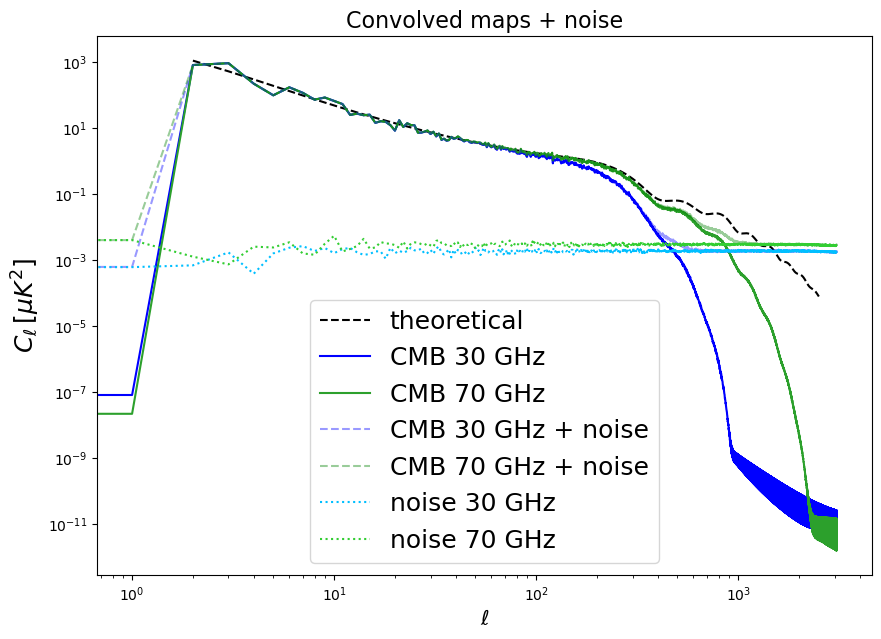

In [65]:
plt.figure(figsize=(10,7))
plt.plot(lPLA, ClPLA,color='black', ls='--', label='theoretical')

plt.plot(ll, Cls_map0, color='blue', ls='-', label='CMB 30 GHz')
plt.plot(ll, Cls_map1, color='tab:green', ls='-', label='CMB 70 GHz')
plt.plot(ll, Cls_map0_n, color='blue', alpha=0.4, ls='--', label='CMB 30 GHz + noise')
plt.plot(ll, Cls_map1_n, color='green', alpha=0.4, ls='--', label='CMB 70 GHz + noise')

plt.plot(ll, Cls_map_noise0, color='deepskyblue', ls=':', label='noise 30 GHz')
plt.plot(ll, Cls_map_noise1, color='limegreen', ls=':', label='noise 70 GHz')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\ell$', fontsize=15)
plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
plt.title('Convolved maps + noise', fontsize=16)
plt.legend(fontsize=18)
plt.show()

In [66]:
#CHECK: noise Cls
cut=int(2e3) # need to cut our pixelization effects

ACls30_th=pixArea_rad*sigma30**2  #theoretical Cls amplitude
ACls70_th=pixArea_rad*sigma70**2
ACls_diff_th=ACls70_th+ACls30_th

Anoise0_fit=np.mean(Cls_map_noise0[10:cut]) #noise amplitude from fit of Cls
Anoise1_fit=np.mean(Cls_map_noise1[10:cut])
Anoise10_fit=np.mean(Cls_map_noise10[10:cut])

pixArea_rad=hp.nside2pixarea(nside)

print('Constant noise:      30 GHz                        70 GHz                70-30 diff.')
print('Cls noise amplitude fit:   ', Anoise0_fit,'\t', Anoise1_fit,'\t', Anoise10_fit )
print('Cls noise amplitude th:    ', ACls30_th,'\t', ACls70_th, '\t', ACls_diff_th)
print('difference:      ',Anoise0_fit-ACls30_th,'\t',  Anoise1_fit-ACls70_th, '\t', Anoise10_fit-ACls_diff_th)
print('relative diff:   ',(Anoise0_fit-ACls30_th)/Anoise0_fit,'\t\t',  (Anoise1_fit-ACls70_th)/Anoise1_fit,'\t\t', (Anoise10_fit-ACls_diff_th)/Anoise10_fit )


Constant noise:      30 GHz                        70 GHz                70-30 diff.
Cls noise amplitude fit:    0.0018262672759015107 	 0.002889340735027466 	 0.00471524725557381
Cls noise amplitude th:     0.0018284660622697186 	 0.0028897226910646326 	 0.004718188753334351
difference:       -2.198786368207877e-06 	 -3.819560371663526e-07 	 -2.9414977605413464e-06
relative diff:    -0.0012039784084301008 		 -0.00013219487495396478 		 -0.0006238268326362428


<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_128914/1794855808.py:8: SyntaxWarning: invalid escape sequence '\s'
  plt.hlines(ACls30_th,ll[0], ll[-1], colors='blue', label='$\sigma_{30GHz}^2\Delta\Omega_{pix}$')
/tmp/ipykernel_128914/1794855808.py:9: SyntaxWarning: invalid escape sequence '\s'
  plt.hlines(ACls70_th,ll[0], ll[-1], colors='tab:green', label='$\sigma_{70GHz}^2\Delta\Omega_{pix}$')
/tmp/ipykernel_128914/1794855808.py:10: SyntaxWarning: invalid escape sequence '\s'
  plt.hlines(ACls_diff_th,ll[0], ll[-1], colors='tab:red', label='$(\sigma_{30GHz}^2+\sigma_{70GHz}^2)\Delta\Omega_{pix}$')
/tmp/ipykernel_1289

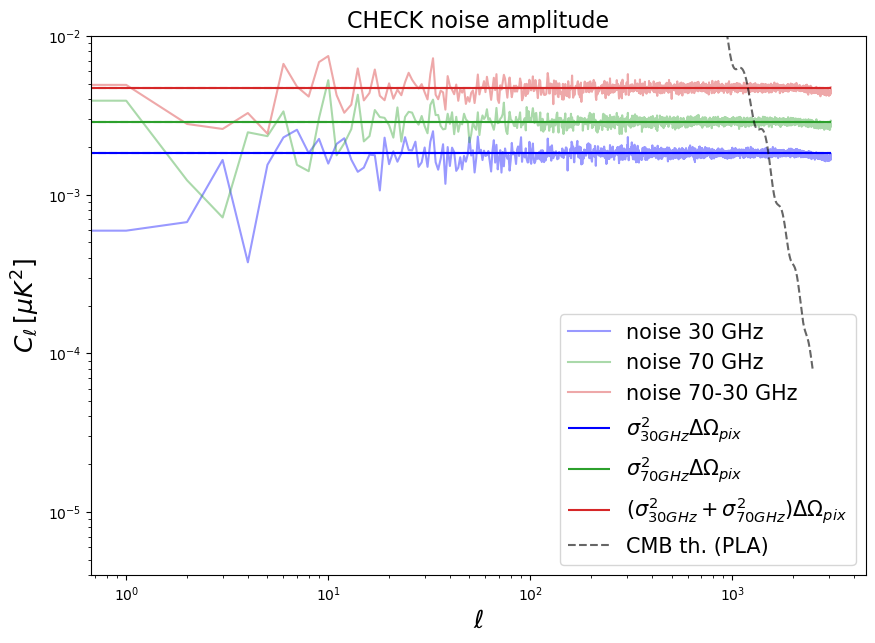

In [67]:
#### CHECK: that noise is constant = sigma_pix² DeltaOmega_pix
plt.figure(figsize=(10,7))

plt.plot(ll, Cls_map_noise0, color='blue', alpha=0.4, ls='-', label='noise 30 GHz')
plt.plot(ll, Cls_map_noise1, color='tab:green', alpha=0.4, ls='-', label='noise 70 GHz')
plt.plot(ll, Cls_map_noise10, color='tab:red', alpha=0.4, ls='-', label='noise 70-30 GHz')

plt.hlines(ACls30_th,ll[0], ll[-1], colors='blue', label='$\sigma_{30GHz}^2\Delta\Omega_{pix}$')
plt.hlines(ACls70_th,ll[0], ll[-1], colors='tab:green', label='$\sigma_{70GHz}^2\Delta\Omega_{pix}$')
plt.hlines(ACls_diff_th,ll[0], ll[-1], colors='tab:red', label='$(\sigma_{30GHz}^2+\sigma_{70GHz}^2)\Delta\Omega_{pix}$')

plt.hlines(Anoise0_fit,ll[0], ll[-1], colors='blue', ls='--')
plt.hlines(Anoise1_fit,ll[0], ll[-1], colors='tab:green', ls='--' )
plt.hlines(Anoise10_fit,ll[0], ll[-1], colors='tab:red',ls='--' )

plt.plot(lPLA, ClPLA,color='black', ls='--', alpha=0.6, label='CMB th. (PLA)',zorder=10)


plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\ell$', fontsize=18)
plt.ylim(4e-6, 1e-2)
plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
plt.title('CHECK noise amplitude', fontsize=16)
plt.legend(fontsize=15, loc='lower right')
plt.show()

In [68]:
### DECONVOLVED NOISE: 

# deconvolved noise maps
map_noise0_dec=hp.sphtfunc.smoothing(map_noise0, beam_window=1/np.sqrt(Cls_beam0_cut), lmax=lmax_cut0-1)  
map_noise1_dec=hp.sphtfunc.smoothing(map_noise1, beam_window=1/np.sqrt(Cls_beam1_cut), lmax=lmax_cut0-1)

Cls_map_noise0_dec=hp.anafast(map_noise0_dec, lmax=lmax_cut0-1)
Cls_map_noise1_dec=hp.anafast(map_noise1_dec, lmax=lmax_cut0-1)
Cls_map_noise10_dec=Cls_map_noise0_dec+Cls_map_noise1_dec

#expected deconvolved noise maos (smooth curves from theoretical values)
Cls_noise0_dec_th=np.full(lmax_cut0, ACls30_th)/Cls_beam0_cut[:lmax_cut0] 
Cls_noise1_dec_th=np.full(lmax_cut0, ACls70_th)/Cls_beam1_cut[:lmax_cut0]
Cls_noise10_dec_th=Cls_noise0_dec_th+Cls_noise1_dec_th 

#EXPECTED deconvolved noisy maps (neglecting beam effects = perfect deconvolution)
Cls0n_dec_th=ClPLA[:lmax_cut0-2]+Cls_noise0_dec_th[2:] #expected deconvolved maps (neglecting beam effects)
Cls1n_dec_th=ClPLA_xi[:lmax_cut0-2]+Cls_noise1_dec_th[2:]


<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_128914/1247603849.py:21: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$', fontsize=18)


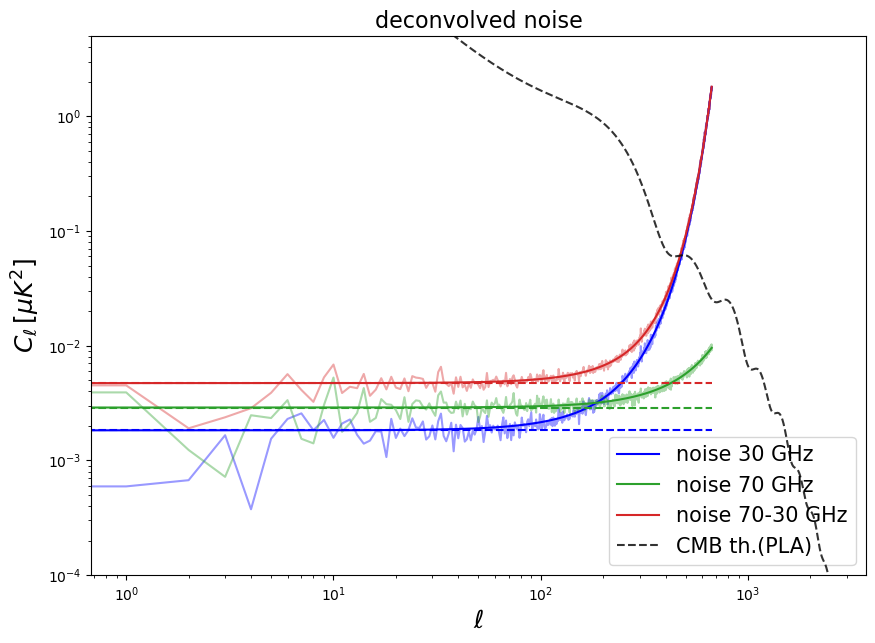

In [69]:
#### PLOT: deconvolved noise
plt.figure(figsize=(10,7))
plt.plot(ll_cut, Cls_map_noise0_dec, color='blue', alpha=0.4, ls='-')
plt.plot(ll_cut, Cls_map_noise1_dec, color='tab:green', alpha=0.4, ls='-')
plt.plot(ll_cut, Cls_map_noise10_dec, color='tab:red', alpha=0.4, ls='-')

plt.plot(ll_cut, Cls_noise0_dec_th, color='blue', ls='-', label='noise 30 GHz')
plt.plot(ll_cut, Cls_noise1_dec_th, color='tab:green', ls='-', label='noise 70 GHz')
plt.plot(ll_cut, Cls_noise10_dec_th, color='tab:red', ls='-', label='noise 70-30 GHz')

plt.hlines(Anoise0_fit,ll[0], lmax_cut0, colors='blue', ls='--')
plt.hlines(Anoise1_fit,ll[0], lmax_cut0, colors='tab:green', ls='--' )
plt.hlines(Anoise10_fit,ll[0], lmax_cut0, colors='tab:red',ls='--' )

plt.plot(lPLA, ClPLA,color='black', ls='--', alpha=0.8, label='CMB th.(PLA)',zorder=10)


plt.ylim(1e-4, 5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
plt.title('deconvolved noise', fontsize=16)
plt.legend(fontsize=15, loc='lower right')
plt.show()

# Deconvolution

Performed with a symmertryzed beams: $a_{lm}^{\rm{dec}}=a_{lm}^{\rm{conv}}/\sqrt{C_l^{\rm{beam}}}\qquad\longrightarrow\qquad C_l^{\rm{dec}}=C_l^{\rm{conv}}/C_l^{\rm{beam}}$

- normalize beams (PLA beam maps are already normalized in steradians but not very precisely) $\quad\longrightarrow\quad C_l^{\rm{beam}}=4\pi$ hp.anafast(beam_map)     should be $=1$ on large scales (checked)
- cut high bultipoles: $C_l^{\rm{beam}}<$ threshold  -  <font color="red">Possible problem: Cls_beam have orders of magnitude difference for the same cut</font>
- deconvolve: deconvolved Cls should coincide with the theoretical ones. If they don't these are beam and noise effects.  



Analyze 4 cases: 
1) realistic beam + noise
2) realistic beam, noiseless
3) symmetric beam + noise
4) symmetric beam, noiseless

In [70]:
##### DECONVOLVE with hp.smoothing 

#realistic beam + noise 
map0_n_dec=hp.sphtfunc.smoothing(map0_n, beam_window=1/np.sqrt(Cls_beam0_cut), lmax=lmax_cut0-1)  # deconvolved noisy maps
map1_n_dec=hp.sphtfunc.smoothing(map1_n, beam_window=1/np.sqrt(Cls_beam1_cut), lmax=lmax_cut0-1)
map10_n=map1_n_dec-map0_n_dec

Cls_map0_n_dec=hp.anafast(map0_n_dec, lmax=lmax_cut0-1) 
Cls_map1_n_dec=hp.anafast(map1_n_dec, lmax=lmax_cut0-1)
Cls_map10_n=hp.anafast(map10_n, lmax=lmax_cut0-1)

#realistic beam (noiseless)
map0_dec=hp.sphtfunc.smoothing(map0, beam_window=1/np.sqrt(Cls_beam0_cut), lmax=lmax_cut0-1)  # deconvolved noisy maps
map1_dec=hp.sphtfunc.smoothing(map1, beam_window=1/np.sqrt(Cls_beam1_cut), lmax=lmax_cut0-1)
map10=map1_dec-map0_dec

Cls_map0_dec=hp.anafast(map0_dec, lmax=lmax_cut0-1)
Cls_map1_dec=hp.anafast(map1_dec, lmax=lmax_cut0-1)
Cls_map10=hp.anafast(map10, lmax=lmax_cut0-1)

#symmetric beam + noise
map0symm_n_dec=hp.sphtfunc.smoothing(map0symm_n, beam_window=1/np.sqrt(Cls_beam0_cut), lmax=lmax_cut0-1)  # deconvolved noisy maps
map1symm_n_dec=hp.sphtfunc.smoothing(map1symm_n, beam_window=1/np.sqrt(Cls_beam1_cut), lmax=lmax_cut0-1)
map10symm_n=map1symm_n_dec-map0symm_n_dec

Cls_map0symm_n_dec=hp.anafast(map0symm_n_dec, lmax=lmax_cut0-1) 
Cls_map1symm_n_dec=hp.anafast(map1symm_n_dec, lmax=lmax_cut0-1)
Cls_map10symm_n=hp.anafast(map10symm_n, lmax=lmax_cut0-1)


#symmetric beam (noiseless)
map0symm_dec=hp.sphtfunc.smoothing(map0symm, beam_window=1/np.sqrt(Cls_beam0_cut), lmax=lmax_cut0-1)  # deconvolved noisy maps
map1symm_dec=hp.sphtfunc.smoothing(map1symm, beam_window=1/np.sqrt(Cls_beam1_cut), lmax=lmax_cut0-1)
map10symm=map1symm_dec-map0symm_dec

Cls_map0symm_dec=hp.anafast(map0symm_dec, lmax=lmax_cut0-1) 
Cls_map1symm_dec=hp.anafast(map1symm_dec, lmax=lmax_cut0-1)
Cls_map10symm=hp.anafast(map10symm, lmax=lmax_cut0-1)

<>:63: SyntaxWarning: invalid escape sequence '\e'
<>:67: SyntaxWarning: invalid escape sequence '\e'
<>:63: SyntaxWarning: invalid escape sequence '\e'
<>:67: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_128914/363075768.py:63: SyntaxWarning: invalid escape sequence '\e'
  ax[i].set_xlabel('$\ell$', fontsize=18)
/tmp/ipykernel_128914/363075768.py:67: SyntaxWarning: invalid escape sequence '\e'
  fig.suptitle('CMB deconvolved maps, $\ell_{max}=$'+str(lmax_cut0), fontsize=18, fontweight='bold')


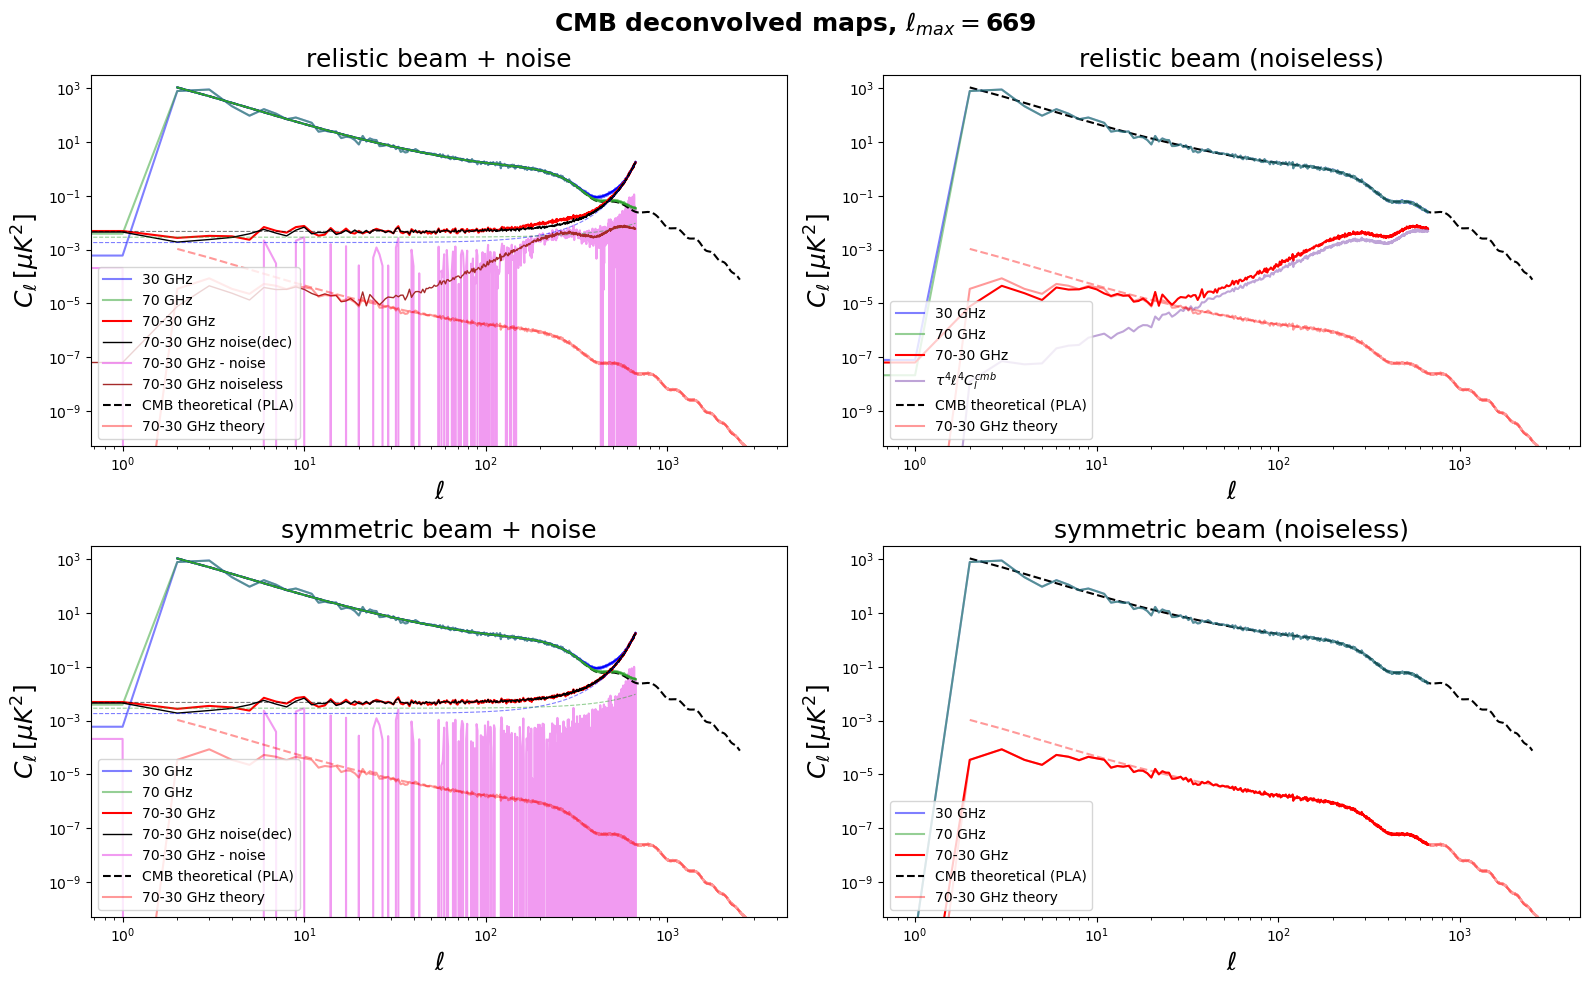

In [71]:
### PLOT deconvolved maps 
fig, ax = plt.subplots(2, 2, figsize=(16, 10))
ax = ax.flatten()

#deconvolved maps
ax[0].plot(ll_cut, Cls_map0_n_dec, color='blue', ls='-', alpha=0.5, label='30 GHz') 
ax[0].plot(ll_cut, Cls_map1_n_dec, color='tab:green', ls='-', alpha=0.5, label='70 GHz')
ax[1].plot(ll_cut, Cls_map0_dec, color='blue', ls='-', alpha=0.5, label='30 GHz') 
ax[1].plot(ll_cut, Cls_map1_dec, color='tab:green', ls='-', alpha=0.5, label='70 GHz')
ax[2].plot(ll_cut, Cls_map0symm_n_dec, color='blue', ls='-', alpha=0.5, label='30 GHz') 
ax[2].plot(ll_cut, Cls_map1symm_n_dec, color='tab:green', ls='-', alpha=0.5, label='70 GHz')
ax[3].plot(ll_cut, Cls_map0symm_dec, color='blue', ls='-', alpha=0.5, label='30 GHz')
ax[3].plot(ll_cut, Cls_map1symm_dec, color='tab:green', ls='-', alpha=0.5, label='70 GHz')

ax[0].plot(ll_cut[2:], Cls0n_dec_th, color='blue', ls='-') #expecetd smooth curves (not fits): ClsPLA+Cls_noise/Cls_beam
ax[0].plot(ll_cut[2:], Cls1n_dec_th, color='tab:green', ls='-')
ax[2].plot(ll_cut[2:], Cls0n_dec_th, color='blue', ls='-') 
ax[2].plot(ll_cut[2:], Cls1n_dec_th, color='tab:green', ls='-')

#difference maps
ax[0].plot(ll_cut, Cls_map10_n, color='red', ls='-',  label='70-30 GHz') 
ax[1].plot(ll_cut, Cls_map10, color='red', ls='-',  label='70-30 GHz') 
ax[2].plot(ll_cut, Cls_map10symm_n, color='red', ls='-',  label='70-30 GHz') 
ax[3].plot(ll_cut, Cls_map10symm, color='red', ls='-',  label='70-30 GHz') 

ax[1].plot(ll_cut,  (tau_th**4)*(ll_cut**4)*Cls_map_cmb[:lmax_cut0], color='tab:purple', alpha=0.6, ls='-',  label=r'$\tau^4\ell^4 C_l^{cmb}$')  ### ATTEMPT

#noise 
for i in [0, 2]:
    ax[i].plot(ll_cut, Cls_map_noise10_dec, color='black', ls='-', lw=1,   label='70-30 GHz noise(dec)') #difference map noise
    ax[i].plot(ll_cut, Cls_noise0_dec_th, color='blue', alpha=0.5, ls='--', lw=0.8)  #noise curves
    ax[i].plot(ll_cut, Cls_noise1_dec_th, color='tab:green',  alpha=0.5,  ls='--', lw=0.8)
    ax[i].plot(ll_cut, Cls_noise10_dec_th, color='black', alpha=0.5,  ls='--', lw=0.8)

#noise subtraction
ax[0].plot(ll_cut, Cls_map10_n-Cls_noise10_dec_th, color='violet', alpha=0.8, ls='-', lw=1.5, label='70-30 GHz - noise', zorder=0)
ax[0].plot(ll_cut, Cls_map10, color='brown', ls='-',lw=1.,  label='70-30 GHz noiseless') 
ax[2].plot(ll_cut, Cls_map10symm_n-Cls_noise10_dec_th, color='violet', alpha=0.8, ls='-', lw=1.5, label='70-30 GHz - noise', zorder=0)


#difference between Cls
cdiff='tab:purple'
'''
ax[0].plot(ll_cut, -(Cls_map1_n_dec-Cls_map0_n_dec), color=cdiff, ls='-',  label='-($C_l^{70 GHz}-C_l^{30 GHz}$)') 
ax[1].plot(ll_cut, -(Cls_map1_dec-Cls_map0_dec), color=cdiff, ls='-',  label='($C_l^{70 GHz}-C_l^{30 GHz}$)') 
ax[2].plot(ll_cut, -(Cls_map1symm_n_dec-Cls_map0symm_n_dec), color=cdiff, ls='-',  label='($C_l^{70 GHz}-C_l^{30 GHz}$)') 
ax[3].plot(ll_cut, -(Cls_map1symm_dec-Cls_map0symm_dec), color=cdiff, ls='-',  label='($C_l^{70 GHz}-C_l^{30 GHz}$)') 
'''

#plot titles
ax[0].set_title('relistic beam + noise', fontsize=18)
ax[1].set_title('relistic beam (noiseless)', fontsize=18)
ax[2].set_title('symmetric beam + noise', fontsize=18)
ax[3].set_title('symmetric beam (noiseless)', fontsize=18)

for i in range(4):
    ax[i].plot(lPLA, ClPLA, color='black', ls='--', label='CMB theoretical (PLA)', zorder=0)  #PLA CMB Cls 
    ax[i].plot(ll, Cls_mapdiff_th, color='red', alpha=0.4, ls='-',  label='70-30 GHz theory') #theoretical map difference
    ax[i].plot(lPLA, tau_th**2*ClPLA, color='red', alpha=0.4, ls='--') 
    ax[i].set_ylim(5e-11, 3e3)
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
    ax[i].set_xlabel('$\ell$', fontsize=18)
    ax[i].set_ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
    ax[i].legend(fontsize=10)

fig.suptitle('CMB deconvolved maps, $\ell_{max}=$'+str(lmax_cut0), fontsize=18, fontweight='bold')
fig.tight_layout()
plt.show()

Realistic beam + noise: 
- Deconvolved maps (blue, green): the noise is amplified on small scales by beam deconvolution. The effect is more noticeable for the 30 GHz map, even if the noise variance is lower, because the beam is larger therefore its Cls are lower at $l_{cut}$
- Cls of the difference map (red): <font color="blue">2) the difference map is noise-dominated at most multipoles </font>  // the ideal ones are computed from the theoretical realizations of the two maps (before convolution) // <font color="red">2) if the signal in the difference map is below the noise, then why do I see the bump around ell=100 </font>
- Expected smooth curves. 30 GHz map: $C_l^{dec}=C_l^{PLA}+C_l^{N_1}/C_l^{beam_1}$ // Noise of the difference map: $C_l^{N_{1-2} dec} = C_l^{N_1}/C_l^{beam_1}+C_l^{N_2}/C_l^{beam_2}$ // <font color="red"> compute this: need to subtract the cross-correlation between the two maps too </font> - they all coincide with the Cls found from the maps. 

Realistic beam (noiseless): 
- Cls of the difference map $C_\ell^{ji}=[|\tau|^2+|\delta\epsilon_{lm}|^2-2\tau\rm{Re}(\delta\epsilon_{lm})]C_l^{\rm{CMB}}$
- Difference map (red): same amplitude as the theoretical ones until $\ell\sim 30$ // <font color="red"> after there is a discrepancy - can't explain it</font>. Beam residuals $\sim \tau^4\ell^4C_\ell^{cmb}$     $\longrightarrow |\delta\epsilon_{lm}|^2\sim \tau^4\ell^4$
- Deconvolved maps (blue, green): the plots coincide with theoretical Cls - confirms that the deviation in the realiztic case is caused by the noise

$|\delta\epsilon_{lm}|^2 = \langle(\epsilon_{lm}^1-\epsilon_{lm}^0)^*(\epsilon_{lm}^1-\epsilon_{lm}^0)\rangle = |\delta\epsilon_{lm}^1|^2 + |\delta\epsilon_{lm}^0|^2 - \langle \epsilon_{lm}^1 \epsilon_{lm}^0\rangle - \langle \epsilon_{lm}^0 \epsilon_{lm}^1\rangle $ 



<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:22: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_128914/1439680097.py:22: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$', fontsize=25)


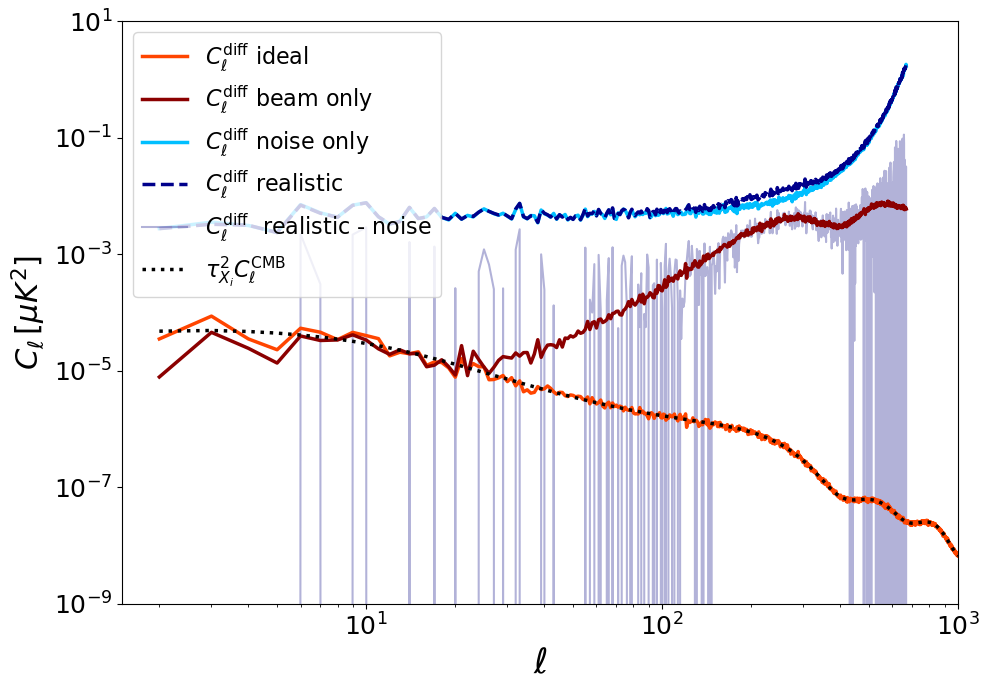

In [72]:
### PLOT FOR PAPER
fig = plt.figure(1, figsize=(10, 7))
#difference maps
plt.plot(ll[2:], Cls_mapdiff_th[2:], color='orangered', ls='-', lw=2.5 , label=r'$C_\ell^{\rm{diff}}$ ideal') # ideal 
plt.plot(ll_cut[2:], Cls_map10[2:], color='darkred', ls='-', lw=2.5, label=r'$C_\ell^{\rm{diff}}$ beam only') # realistic beam, noiseless
plt.plot(ll_cut[2:], Cls_map10symm_n[2:], color='deepskyblue', ls='-', lw=2.5, label=r'$C_\ell^{\rm{diff}}$ noise only')  #noise only, summ beam
plt.plot(ll_cut[2:], Cls_map10_n[2:], color='darkblue', ls='--', lw=2.5,  label=r'$C_\ell^{\rm{diff}}$ realistic')  #realistic beam + noise
plt.plot(ll_cut[2:], Cls_map10_n[2:]-Cls_noise10_dec_th[2:], color='navy', alpha=0.3, ls='-', lw=1.5, label=r'$C_\ell^{\rm{diff}}$  realistic - noise ', zorder=0)  # realistic beam + noise, with noise model subtraction

#attempt of modeling beam residuals
#plt.plot(ll_cut,  (tau_th**4)*(ll_cut**4)*Cls_map_cmb[:lmax_cut0], color='blue', ls=':',  label=r'$\tau^4\ell^4 C_l^{cmb}$')  ### ATTEMPT of beam res. modeling
plt.plot(lPLA, tau_l[2:int(lPLA[-1]+1)]**2*ClPLA,color='black', ls=':', lw=2.5, label=r'$\tau_{X_i}^2 C_\ell^{\rm{CMB}}$')  #theoretical from PLA

#fit_attempt=tau_l[2:int(lPLA[-1]+1)]**2*ClPLA  +  lPLA**4*tau_l[2:int(lPLA[-1]+1)]**4*ClPLA
#plt.plot(lPLA, fit_attempt ,color='tab:purple', alpha=0.7, ls='-', zorder=0, lw=2, label=r'$\tau^2C_\ell^{\rm{CMB}}+ \tau^4 \ell^4 C_\ell^{\rm{CMB}}$')  #theoretical from PLA


plt.ylim(1e-9, 10)
plt.xlim(1.5, 1e3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\ell$', fontsize=25)
plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=22)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=16, loc='upper left')
plt.tight_layout()


plt.savefig("/home/evanetti/BEAMS/paper_figures/Clsdiff_all.pdf", format="pdf", bbox_inches="tight")

plt.show()

## PLOTS for paper

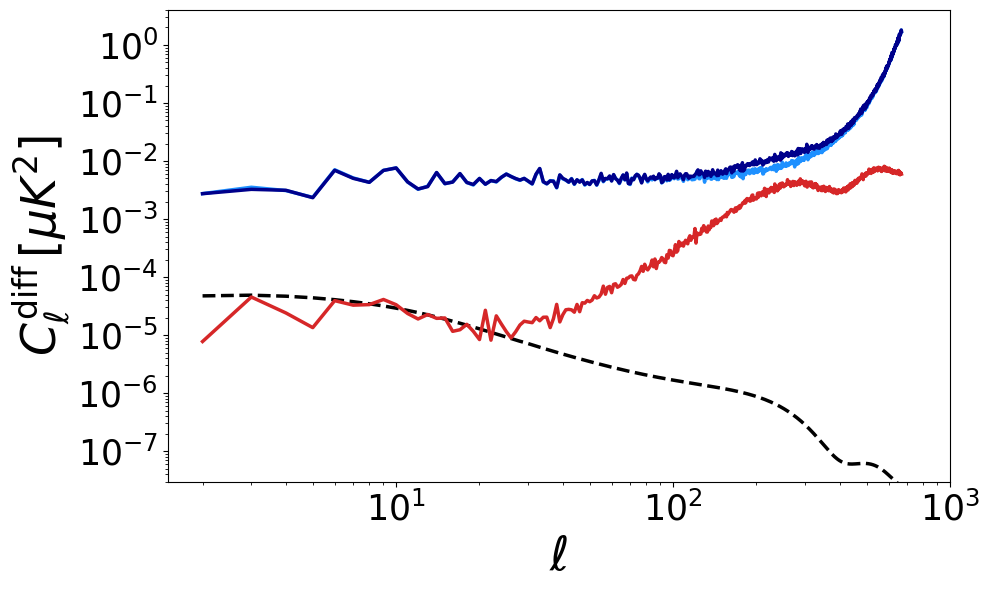

In [98]:
### PLOT FOR PAPER
fig = plt.figure( figsize=(10, 6))

#attempt of modeling beam residuals
plt.plot(lPLA, tau_l[2:int(lPLA[-1]+1)]**2*ClPLA,color='black', ls='--', lw=2.5, label=r'theory')  #theoretical from PLA


#difference maps
#plt.plot(ll[2:], Cls_mapdiff_th[2:], color='lightgray', ls='-', lw=2.5 , label=r'ideal') #diff map - initial relaization
plt.plot(ll_cut[2:], Cls_map10[2:], color='tab:red', ls='-', lw=2.5, label=r'beam res.') #diff map - realistic beam
plt.plot(ll_cut[2:], Cls_map10symm_n[2:], color='dodgerblue', ls='-', lw=2.5, label=r'noise') #diff map - realistic beam
plt.plot(ll_cut[2:], Cls_map10_n[2:], color='darkblue', ls='-', lw=2.5, label=r'beam res. + noise') #diff map - realistic beam



#fit_attempt=tau_l[2:int(lPLA[-1]+1)]**2*ClPLA  +  lPLA**4*tau_l[2:int(lPLA[-1]+1)]**4*ClPLA
#plt.plot(lPLA, fit_attempt ,color='lightsteelblue', alpha=1., ls='-', zorder=0, lw=2.5, label=r'$\tau_{X_i}^2C_\ell^{\rm{CMB}}+ \tau_{X_i}^4 \ell^4 C_\ell^{\rm{CMB}}$')  #theoretical from PLA

plt.ylim(3e-8, 4)
plt.xlim(1.5, 1e3)
plt.xscale('log')
plt.yscale('log')
#plt.legend(fontsize=22)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.xlabel(r'$\ell$', fontsize=34)
plt.ylabel(r'$C_\ell^{\rm diff}\,[\mu K^2]$', fontsize=34) 

plt.tight_layout()

plt.savefig('ClsCMB.png',dpi=300, bbox_inches='tight',  format='png')


plt.savefig("/home/evanetti/BEAMS/paper_figures/Clsdiff_realbeam", dpi=300, bbox_inches="tight")

plt.show()

In [73]:
## compute cross-scpectrum (neede for matched filtering)
Cls_cross_th = hp.anafast(mapdiff_th, map_cmb, lmax=lmax_cut0-1)
Cls_cross_real_n = hp.anafast(map10_n, map0_n_dec, lmax=lmax_cut0-1)
Cls_cross_real = hp.anafast(map10, map0_dec, lmax=lmax_cut0-1)
Cls_cross_symm_n = hp.anafast(map10symm_n, map0symm_n_dec, lmax=lmax_cut0-1)

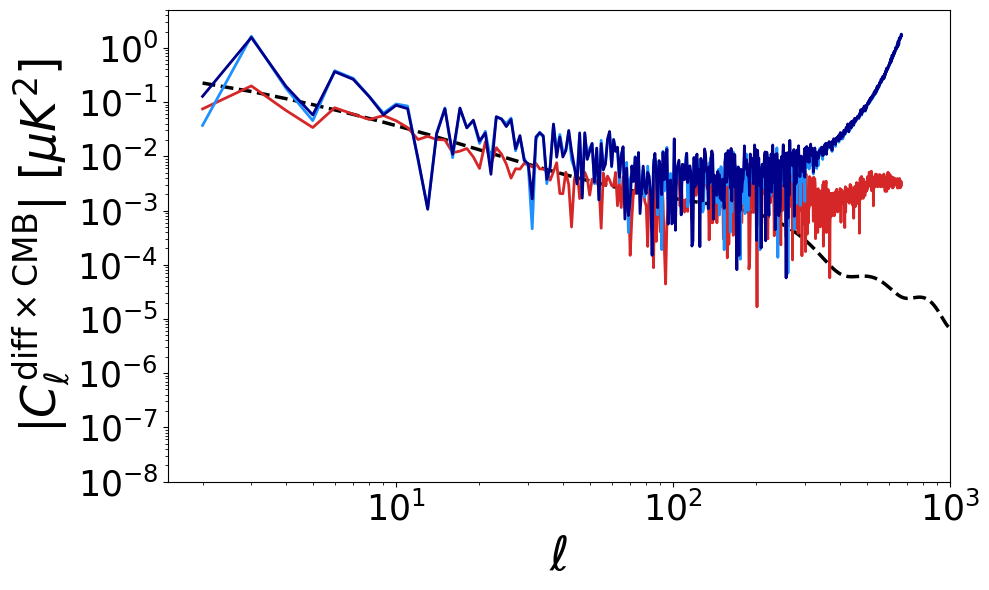

In [ ]:
## PLOT FOR PAPER
fig = plt.figure( figsize=(10, 6))

#attempt of modeling beam residuals
plt.plot(lPLA, tau_l[2:int(lPLA[-1]+1)]*ClPLA,color='black', ls='--', lw=2.5, label=r'theory')  #theoretical from PLA


#difference maps
#plt.plot(ll_cut[2:], np.absolute(Cls_cross_th[2:]), color='lightgray', ls='-', lw=2.5 , label=r'ideal') #diff map - initial relaization
plt.plot(ll_cut[2:], np.absolute(Cls_cross_real[2:]), color='tab:red', ls='-', lw=2, label=r'beam res.') #diff map - realistic beam
plt.plot(ll_cut[2:], np.absolute(Cls_cross_symm_n[2:]), color='dodgerblue', ls='-', lw=2, label=r'noise') #diff map - realistic beam
plt.plot(ll_cut[2:], np.absolute(Cls_cross_real_n[2:]), color='darkblue', ls='-', lw=2, label=r'beam res. + noise') #diff map - realistic beam

#plt.axvspan(0, 50, hatch='///', fill=False, edgecolor='lightgray')
#plt.axvspan(250, 1e3, hatch='///', fill=False, edgecolor='lightgray')

#fit_attempt=tau_l[2:int(lPLA[-1]+1)]**2*ClPLA  +  lPLA**4*tau_l[2:int(lPLA[-1]+1)]**4*ClPLA
#plt.plot(lPLA, fit_attempt ,color='lightsteelblue', alpha=1., ls='-', zorder=0, lw=2.5, label=r'$\tau_{X_i}^2C_\ell^{\rm{CMB}}+ \tau_{X_i}^4 \ell^4 C_\ell^{\rm{CMB}}$')  #theoretical from PLA

plt.ylim(3e-8, 4)
plt.xlim(1.5, 1e3)
plt.xscale('log')
plt.yscale('log')
#plt.legend(fontsize=22)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.xlabel(r'$\ell$', fontsize=34)
plt.ylabel(r'$|C_\ell^{\rm{diff}\times\rm{CMB}}|\,\,[\mu K^2]$', fontsize=34) 

plt.tight_layout()

plt.savefig('ClsCMB.png',dpi=300, bbox_inches='tight',  format='png')


plt.savefig("/home/evanetti/BEAMS/paper_figures/Clscross", dpi=300, bbox_inches="tight")

plt.show()

### Expected departure from theoretical Cls, due to noise only

Compute theoretical deconvolved Cls: $\quad C_l^{\rm{dec}}=C_l^{PLA}+C_l^N/C_l^b\quad$   
neglects accidental correlations between noise and CMB

Difference with ideal case: $\quad C_l^{\rm{dec}}-C_l^{PLA} = C_l^N/C_l^b$ $\qquad\qquad$ Relative difference: $\quad C_l^N/(C_l^b C_l^{PLA}) $ 

Result from smooth analytical spectra:
- large scales: the 70 GHz plot is above since the noise variance is higher
- small scales: the 30 GHz noise is higher becasue of the larger 30 GHz beam which boosts the noise more (beam Cls have lower amplitude at ell_cut)

Verified that the actual maps follow the same trend. Beam effects are subdominant. 


// At which $\ell$ the difference becomes larger than a certain threshold $th$?

$th$   $\qquad  10^{-4} \quad 10^{-3} \quad 5\times 10^{-3} \quad 10^{-2}$   
30 GHz: $\quad 17 \qquad  81 \qquad 216\qquad 256 $   
70 GHz:  $\quad 13 \qquad  58 \qquad 231\qquad 284 $  

DIFFERENCE MAP:  
Theoretical: $a_{\ell m}^{diff}=-\tau\, a_{\ell m}^{cmb} \quad\rightarrow\quad C_\ell^{diff}=\tau^2 C_\ell^{cmb(PLA)} $ 

With noise: $a_{\ell m}^{diff}=a_{\ell m}^{70, dec}-a_{\ell m}^{30, dec}=[(1-\tau)a_{\ell m}^{cmb}+a_{\ell m}^{N_2}/b_\ell^{70}]- [a_{\ell m}^{cmb}+a_{\ell m}^{N_1}/b_\ell^{30}] = -\tau a_{\ell m}^{cmb}+a_{\ell m}^{N_2}/b_\ell^{70} - a_{\ell m}^{N_1}/b_\ell^{30}$

$\longrightarrow \qquad C_\ell^{diff+N}=\tau^2 C_\ell^{cmb(PLA)}+C_\ell^{N_1}/C_\ell^{b70}+C_\ell^{N_2}/C_\ell^{b30}$ neglecting accidental correlation between CMB, N1 and N2

With noise and beam errors: there is a difference in the same area shown in plots above

<>:33: SyntaxWarning: invalid escape sequence '\e'
<>:35: SyntaxWarning: invalid escape sequence '\e'
<>:33: SyntaxWarning: invalid escape sequence '\e'
<>:35: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_10589/2196262102.py:33: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$', fontsize=18)
/tmp/ipykernel_10589/2196262102.py:35: SyntaxWarning: invalid escape sequence '\e'
  plt.title('rel. diff. from PLA due to deconvolved noise, $\ell_{max}=$'+str(lmax_cut0), fontsize=15)


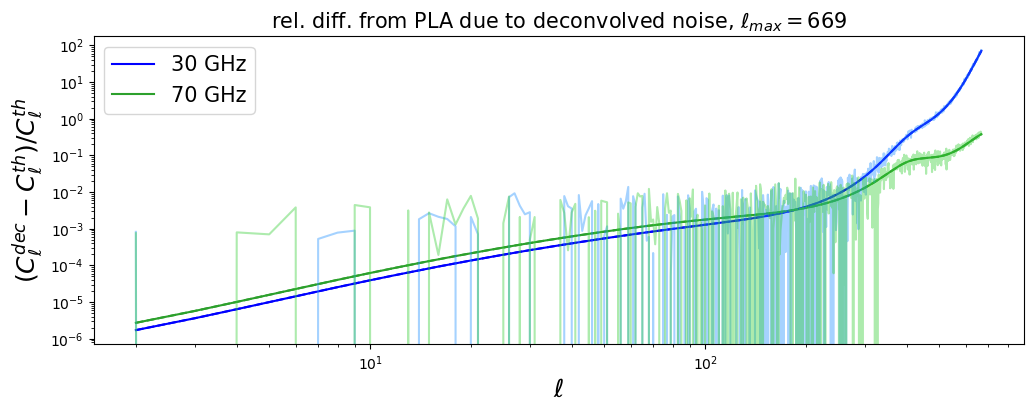

th= 0.0001 	 ll_cut_value= 13
th= 0.001 	 ll_cut_value= 58
th= 0.005 	 ll_cut_value= 231
th= 0.01 	 ll_cut_value= 284


In [ ]:
## deviation from theoretical Cls due to noise
# difference between: deconvolved Cls vs Cls PLA (expected) --> only accounts for difference due to noise
plt.figure(figsize=(12,4))

#theoretical case (smooth analytical spectra)
plt.plot(ll_cut[2:], (Cls0n_dec_th-ClPLA[:lmax_cut0-2])/ClPLA[:lmax_cut0-2] , color='blue', ls='-', label='30 GHz') # this neglects asymmetric beam effects. It's the deviation due to noise
plt.plot(ll_cut[2:], (Cls1n_dec_th-ClPLA_xi[:lmax_cut0-2])/ClPLA_xi[:lmax_cut0-2] , color='tab:green', ls='-', label='70 GHz')
plt.plot(ll_cut[2:], Cls_noise0_dec_th[2:]/ClPLA[:lmax_cut0-2], color='blue', ls='--') 
plt.plot(ll_cut[2:], Cls_noise1_dec_th[2:]/ClPLA_xi[:lmax_cut0-2], color='tab:green', ls='--')


# symmetric beam + noise
plt.plot(ll_cut[2:], (Cls_map0symm_n_dec[2:lmax_cut0]-Cls_map_cmb[2:lmax_cut0])/Cls_map_cmb[2:lmax_cut0],color='dodgerblue', ls='-', alpha=0.4)
plt.plot(ll_cut[2:], (Cls_map1symm_n_dec[2:lmax_cut0]-Cls_map_xi[2:lmax_cut0])/Cls_map_xi[2:lmax_cut0],color='limegreen', ls='-', alpha=0.4)
plt.hlines(0,ll_cut[2], ll_cut[-1], color='k', alpha=0.7, ls='--')

# realistic beam + noise
#plt.plot(ll_cut[2:], (Cls_map0_n_dec[2:]-ClPLA[:lmax_cut0-2])/ClPLA[:lmax_cut0-2] , color='dodgerblue', ls='-', alpha=0.4) # this neglects asymmetric beam effects. It's the deviation due to noise
#plt.plot(ll_cut[2:], (Cls_map1_n_dec[2:]-ClPLA_xi[:lmax_cut0-2])/ClPLA_xi[:lmax_cut0-2] , color='limegreen', ls='-', alpha=0.4)


#difference map: 
'''
Cls_diff_th=tau_l[2:lmax_cut0]**2*ClPLA[:lmax_cut0-2]+Cls_noise0_dec_th[2:]+Cls_noise1_dec_th[2:]
plt.plot(ll_cut[2:], (Cls_noise0_dec_th[2:]+Cls_noise1_dec_th[2:])/(tau_l[2:lmax_cut0]**2*ClPLA[:lmax_cut0-2]) , color='tab:red', ls='-', label='70-30 GHz diff.' )
plt.plot(ll_cut[2:],(Cls_map10symm_n[2:]-tau_l[2:lmax_cut0]**2*ClPLA[:lmax_cut0-2])/(tau_l[2:lmax_cut0]**2*ClPLA[:lmax_cut0-2])  , color='red', ls='-',alpha=0.4,  label='70-30 GHz diff.')
plt.plot(ll_cut[2:],(Cls_map10_n[2:]-tau_l[2:lmax_cut0]**2*ClPLA[:lmax_cut0-2])/(tau_l[2:lmax_cut0]**2*ClPLA[:lmax_cut0-2])  , color='magenta', ls='-',alpha=0.4,  label='70-30 GHz diff.')
'''

plt.xscale('log')
plt.yscale('log')
#plt.yscale('symlog',  linthresh=1e-5)
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$(C_\ell^{dec}-C_\ell^{th})/C_\ell^{th}$', fontsize=18)
plt.title('rel. diff. from PLA due to deconvolved noise, $\ell_{max}=$'+str(lmax_cut0), fontsize=15)
plt.legend(fontsize=15)
plt.show()

## find ell at which deviation>threshold
thrs=1e-4
thrs_list=[1e-4, 1e-3, 5e-3, 1e-2]
for thrs in thrs_list:

    idx = np.where((Cls1n_dec_th-ClPLA_xi[:lmax_cut0-2])/ClPLA_xi[:lmax_cut0-2] > thrs)[0]
    if idx.size > 0:
        ll_cut_value = ll_cut[2 + idx[0]]
    else:
        ll_cut_value = None
    print('th=',thrs ,'\t ll_cut_value=', ll_cut_value)

# find at which ell the noise difference is larger than tau





### Compare: difference from $C_\ell^{\rm{PLA}}$ due to noise vs due to beam residuals

Compare with initial realization of each map 1) $C_\ell^{dec}$ with symm beam + noise  $\qquad$ 2) $C_\ell^{dec}$ with realistic beam, noiseless 

Case of beam residuals only: $a_{\ell m}^{\rm{dec}}=(1+\epsilon_{\ell m})a_{\ell m}^{\rm{th}}\quad\longrightarrow\quad C_\ell^{\rm{dec}}=|1+\epsilon_{\ell m}|^2 C_\ell^{\rm{th}} = (1+\langle\epsilon_{\ell m}\epsilon_{\ell m}^*\rangle + 2\rm{Re}\langle \epsilon_{\ell m} \rangle)C_\ell^{\rm{th}} $

The plots show:
- difference: $ $
- relative difference: $ $
 
true assuming: 1) zero correlation between beam residials and maps, 2) no mixing between different $\ell, m$ s 


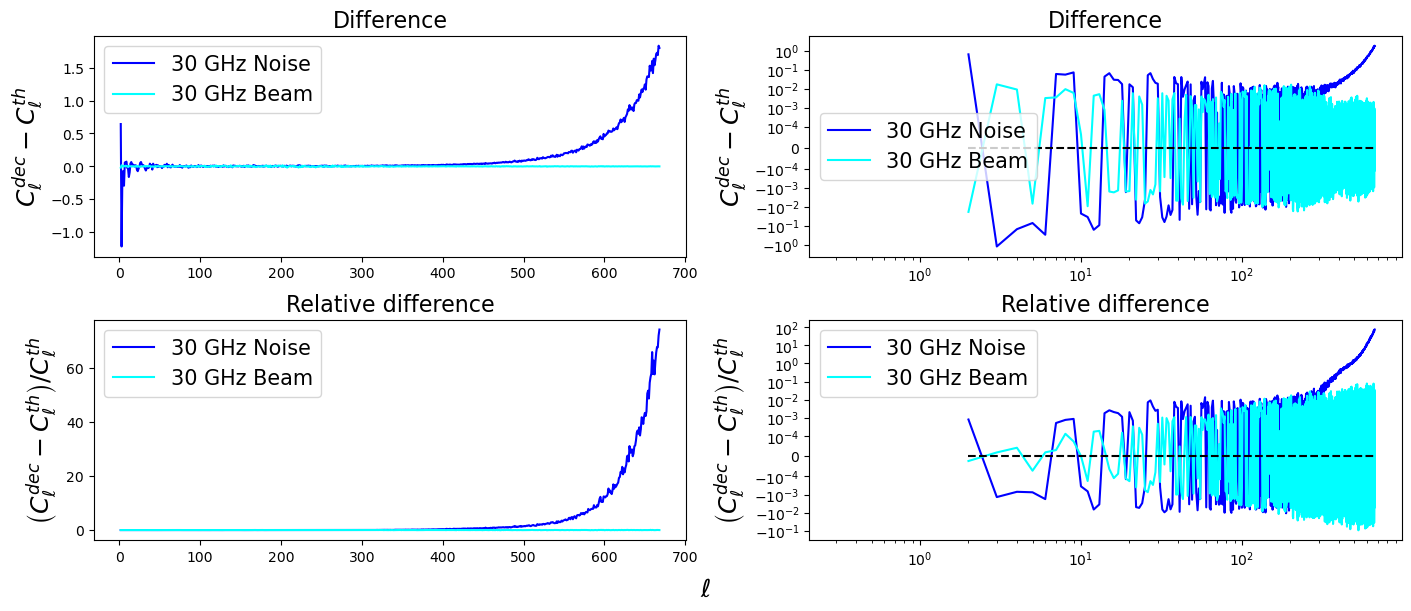

In [ ]:
## 30 GHz channel - DIFFERENCE from original realization - blue) deconvolved Cls with symm beam +  noise

lab_names=['th', 'dec'] #'- 30 GHz - realistic beam vs symmetric beam'
leg_names=['30 GHz Noise', '30 GHz Beam']
colors=['blue', 'cyan']
plot_diff([Cls_map_cmb, Cls_map_cmb], [Cls_map0symm_n_dec, Cls_map0_dec], 2, lmax_cut0, lab_names, leg_names, colors )

'\ncheck error in beam normalization\n\ntry to look at the alms directly\n\ncheck consistrency between epsilon_lm real part average and epslilon_lm squared (other notebook)\n'

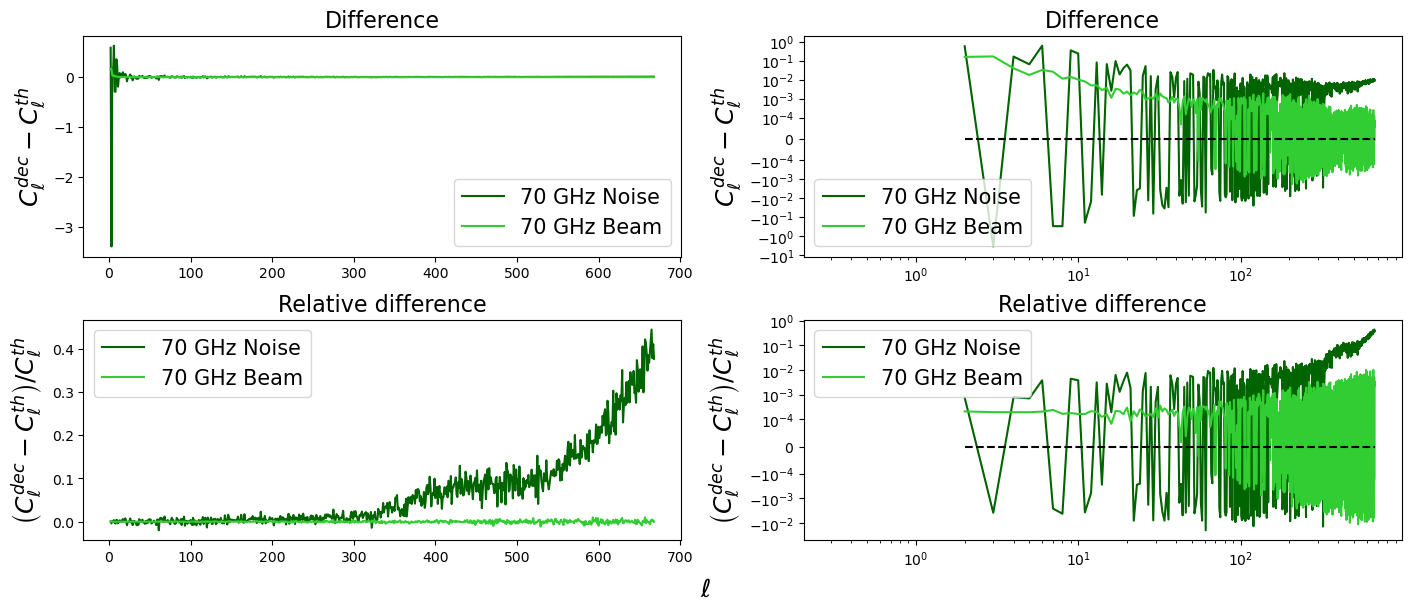

In [ ]:
## 70 GHz channel - DIFFERENCE from original realization - blue) deconvolved Cls with symm beam +  noise

lab_names=['th', 'dec'] #'- 30 GHz - realistic beam vs symmetric beam'
leg_names=['70 GHz Noise', '70 GHz Beam']
colors=['darkgreen', 'limegreen']
plot_diff([Cls_map_xi, Cls_map_xi],[Cls_map1symm_n_dec, Cls_map1_dec], 2, lmax_cut0, lab_names, leg_names, colors)

'''
check error in beam normalization

try to look at the alms directly

check consistrency between epsilon_lm real part average and epslilon_lm squared (other notebook)
'''

In [ ]:
##### CHECK DECONVOLUTION: deconvolve manually
lmax = 3 * nside - 1
print('lmax deconvolved maps = ', lmax, '\tlmax_beam=', len(Cls_beam0))
alm_map0_n = hp.map2alm(map0_n, lmax=lmax_cut0-1)
alm_map1_n = hp.map2alm(map1_n, lmax=lmax_cut0-1)

bl0=1/np.sqrt(Cls_beam0_cut)  #beam transfer functions
bl1=1/np.sqrt(Cls_beam1_cut)

alm_map0_n_dec= hp. almxfl(alm_map0_n,bl0, mmax=lmax_cut0-1)  ###POSSIBLE PROBLEM: lmax beam and alms from map is different
alm_map1_n_dec=hp.almxfl(alm_map1_n,bl1, mmax=lmax_cut0-1) 

map0_n_dec2=hp.alm2map(alm_map0_n_dec, nside=nside, lmax=lmax_cut0-1)
map1_n_dec2=hp.alm2map(alm_map1_n_dec, nside=nside, lmax=lmax_cut0-1)
map10_n_diff2=map1_n_dec2 - map0_n_dec2

#check Cls
Cls_map0_n_dec2=hp.anafast(map0_n_dec2, lmax=lmax_cut0-1)
Cls_map1_n_dec2=hp.anafast(map1_n_dec2, lmax=lmax_cut0-1)
Cls_diff2=hp.anafast(map10_n_diff2, lmax=lmax_cut0-1)

lmax deconvolved maps =  3071 	lmax_beam= 3072


In [ ]:
print(np.min(Cls_map0_n_dec2 - Cls_map0_n_dec), np.max(Cls_map0_n_dec2 - Cls_map0_n_dec))
print(np.min(Cls_map1_n_dec2 - Cls_map1_n_dec), np.max(Cls_map1_n_dec2 - Cls_map1_n_dec))

0.0 0.0
0.0 0.0


In [ ]:
## get alms
alm_map0_dec = hp.map2alm(map0_dec, lmax=lmax_cut0-1)
alm_map1_dec = hp.map2alm(map1_dec, lmax=lmax_cut0-1)
alm_10=hp.map2alm(map10, lmax=lmax_cut0-1)

alm_cmb=hp.map2alm(map_cmb, lmax=lmax_cut0-1)
alm_xi=hp.map2alm(map_xi, lmax=lmax_cut0-1)

In [ ]:
## check alm_xi:
alm_xi_=alm_cmb-hp.almxfl(alm_cmb,tau_l[:lmax_cut0])
check=alm_xi_-alm_xi
print(np.min(check), np.max(check))

(-7.427940929005672e-09+0j) (6.38173958122934e-11+3.357933636011223e-11j)


## Beam residuals

1) compute $\epsilon_{\ell m}$ directly from $a_{\ell m}\!$ s of the convolved maps:  ${a_{\ell m}^{30,\rm{dec}}=a_{\ell m}^{\rm{CMB}}(1+\epsilon_{\ell m}^{30})}\quad,\quad a_{\ell m}^{70,\rm{dec}} = a_{\ell m}^{X_i}(1+\epsilon_{\ell m}^{70})\;\: \text{with} \;\: a_{\ell m}^{X_i}=(1-\tau_{\ell}) a_{\ell m}^{\rm{CMB}}$ 

- $\epsilon_{\ell m}^{30}= \frac{a_{\ell m}^{30,\rm{dec}}}{a_{\ell m}^{\rm{CMB}}}-1 \qquad \qquad \epsilon^{70}_{\ell m}= \frac{a_{\ell m}^{70,\rm{dec}}}{a_{\ell m}^{\rm{X}_i}}-1 $ 

- $| \epsilon_{\ell m}^{30}|^2 = \langle\epsilon_{\ell m}^{30\,*} \epsilon_{\ell m}^{30}\rangle $ is not the full 2-point correlation function, since there it should also have off-diagonal elements.

2) difference map residuals 

<>:27: SyntaxWarning: invalid escape sequence '\e'
<>:27: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_10589/359419980.py:27: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$', fontsize=18)


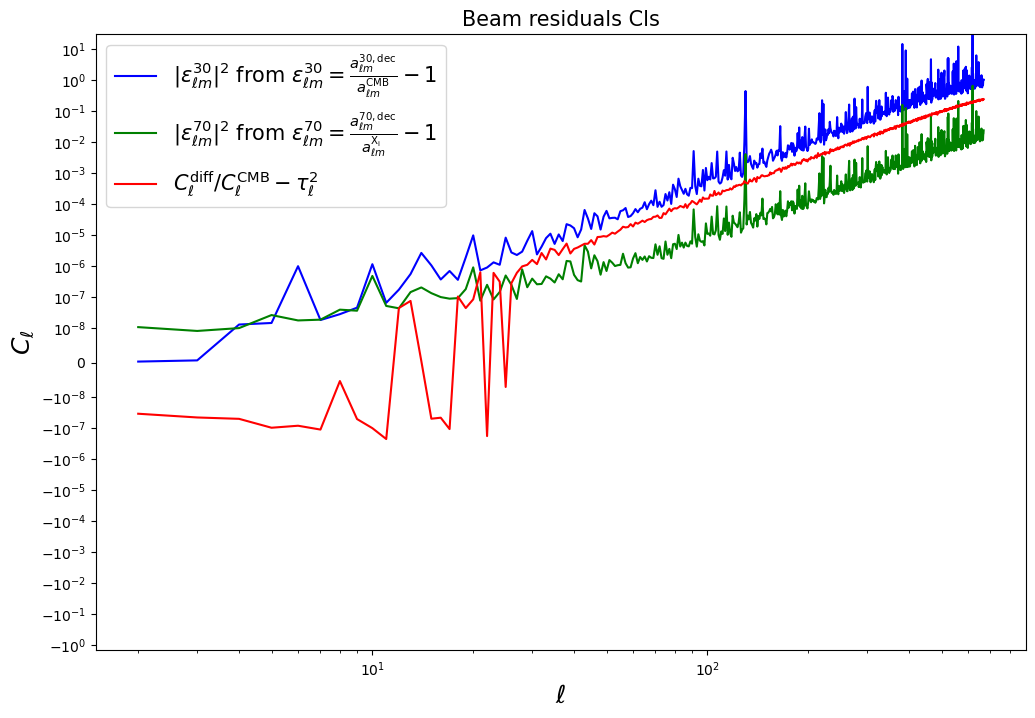

		 l=0 			 l=1 			 l=2
Cls_cmb th:  1.3288855834808194e-12 	 4.322476741658385e-15 	 783.0793573855366
Cls_diff:  1.47906435805216e-07 	 6.39584388402793e-08 	 7.758135628343198e-06


In [ ]:
epslm_0=alm_map0_dec/alm_cmb-1
epslm_1=alm_map1_dec/alm_xi-1

Cls_eps0 = hp.alm2cl(epslm_0)
Cls_eps1 = hp.alm2cl(epslm_1)


plt.figure(figsize=(12,8))
plt.plot(ll_cut[2:], Cls_eps0[2:] , color='blue', ls='-', label=r'$|\epsilon_{\ell m}^{30}|^2$ from $\epsilon_{\ell m}^{30}=\frac{a_{\ell m}^{30,\rm{dec}}}{a_{\ell m}^{\rm{CMB}}}-1 $') 
plt.plot(ll_cut[2:],Cls_eps1[2:] , color='green', ls='-', label=r'$|\epsilon_{\ell m}^{70}|^2$ from $\epsilon_{\ell m}^{70}= \frac{a_{\ell m}^{70,\rm{dec}}}{a_{\ell m}^{\rm{X}_i}}-1$') 

plt.plot(ll_cut[2:], Cls_map10[2:]/Cls_map_cmb[2:lmax_cut0]-tau_l[2:lmax_cut0]**2, color='red', ls='-',  label=r'$C_\ell^{\rm{diff}}/C_\ell^{\rm{CMB}}-\tau_\ell^2$') 
#plt.plot(ll_cut, Cls_map10/Cls_map_cmb[:lmax_cut0]-tau_l[:lmax_cut0]**2, color='red', ls='-',  label=r'$C_\ell^{\rm{diff}}/C_\ell^{\rm{CMB}}-\tau_\ell^2$') 


#plt.plot(ll_cut, Cls_map10, color='magenta', ls='-', label=r'$C_\ell^{\rm{diff}} $')  

#plt.plot(ll_cut, Cls_map_cmb[:lmax_cut0], color='dodgerblue', ls='-', label=r'$C_\ell^{\rm{CMB-th}}$') 
# r'diff: $ |\epsilon_{lm}^1|^2 + |\epsilon_{lm}^0|^2 - 2\rm{Re}(\epsilon_{lm}^0\epsilon_{lm}^1) - 2\tau\rm{Re}(\delta\epsilon_{lm})$'
'''
plt.plot(ll_cut[2:], tau_l[2:lmax_cut0]**2, color='black', ls='--', label=r'70 GHz $\tau_l^2$') 
plt.plot(ll_cut[2:], tau_l[2:lmax_cut0], color='gray', ls=':', label=r'70 GHz $\tau_l$') 
'''
plt.xscale('log')
plt.yscale('symlog', linthresh=1e-8)
#plt.ylim(-1e-6,40)
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$C_\ell$', fontsize=18)
plt.title('Beam residuals Cls', fontsize=15)
plt.legend(fontsize=15)
plt.show()


print('\t\t l=0 \t\t\t l=1 \t\t\t l=2')
print('Cls_cmb th: ', Cls_map_cmb[0] ,'\t',Cls_map_cmb[1] , '\t', Cls_map_cmb[2] )
print('Cls_diff: ', Cls_map10[0] ,'\t',Cls_map10[1] , '\t', Cls_map10[2] )


## CROSS SPECTRUM

In [ ]:
Cl01cross=hp.anafast(map_diff, map0_dec, lmax=lmax_tau-1)     #THEORY
# BEAM ONLY
# NOISE ONLY
# BOTH


# Matched filtering

$E[-\tau] = \frac{\Delta\textbf{T}_{j0}^T C^{-1}T_0}{T_0 C^{-1} \textbf{T}_0} = \frac{\sum_{\hat{n}, \hat{n}'}\Delta T_{j0}^T(\hat{n})C^{-1}_{\hat{n}, \hat{n}'}T_0(\hat{n}') }{\sum_{\hat{n}, \hat{n}'}T_{0}^T(\hat{n})C^{-1}_{\hat{n}, \hat{n}'}T_0(\hat{n}')}$   where $C$ is the covariance matrix $C=\langle d d^\dagger\rangle$, $\Delta T_{j0}$ is from the difference map

In Fourier space
$E[\tau]=-\frac{\sum_\ell (2\ell+1) C_\ell^{\Delta T_{j0}T_0} C_\ell^{-1}}{\sum_\ell  (2\ell+1)  C_\ell^{T_0T_0} C_\ell^{-1}}$

where $C_\ell$ is associated to the covariance matrix

In [ ]:
def tau_estimate(map0_dec, map1_dec, ClNoise, lmin_tau, lmax_tau):
    map_diff=map1_dec-map0_dec  #nota: the two maps need to have the same lmax and nside
    Cl0=hp.anafast(map0_dec, lmax=lmax_tau-1)  #Cls of clean map
    Cl01cross=hp.anafast(map_diff, map0_dec, lmax=lmax_tau-1)     #cross-Cls of clean map with difference map

    l=np.arange(len(Cl0))

    nom_l=(2*l[lmin_tau:]+1)*Cl01cross[lmin_tau:]/ClNoise[lmin_tau:lmax_tau]
    denom_l=(2*l[lmin_tau:]+1)*Cl0[lmin_tau:]/ClNoise[lmin_tau:lmax_tau]
    tau=sum(nom_l)/sum(denom_l)
    sigma_tau=np.sqrt(1/sum(denom_l))

    tau_th=1e-3
    sigma_distance=abs(-tau-tau_th)/sigma_tau
    print(f'E[tau] = {tau:.6f} +- {sigma_tau:4f}  \t sigma distance: {sigma_distance:4f}\t tau interval: [{tau-sigma_tau:.6f} - {tau+sigma_tau:.6f}]')

    ### plot Cls
    norm_l=l*(l+1)/(2*np.pi)
    norm_l=norm_l[lmin_tau:lmax_tau]

    '''
    plt.figure(figsize=(9,6))
    plt.plot(l, Cl01cross/ClNoise[:lmax_tau], label='$C_\ell^{\Delta T_{j0}T_0}/C_\ell^N$', color='red')
    plt.plot(l, Cl0/ClNoise[:lmax_tau], label='$C_\ell^{T_0T_0}/C_\ell^N$', color='gray')  #deconvolved 30GHz map
    plt.plot(l, ClNoise[:lmax_tau], label=r'$C_\ell^N$', color='black', ls='--')
    plt.xscale('log')
    plt.yscale('symlog')
    plt.xlabel('$\ell$', fontsize=18)
    plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
    plt.legend(fontsize=15)
    plt.show()
    '''



    return tau, sigma_tau

<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_128914/1061377793.py:21: SyntaxWarning: invalid escape sequence '\e'
  '''


<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:8: SyntaxWarning: invalid escape sequence '\e'
<>:9: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:8: SyntaxWarning: invalid escape sequence '\e'
<>:9: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_128914/2099749135.py:7: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(ll[:lmax_cut0], Cls_map10_n-Cls_map10symm, color='k', ls='-', lw=2 , label='$C_\ell$') # noise+realistic beam
/tmp/ipykernel_128914/2099749135.py:8: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(ll[:lmax_cut0], Cls_map10-Cls_map10symm, color='r', ls='-', lw=2 , label='$C_\ell$') # beam only

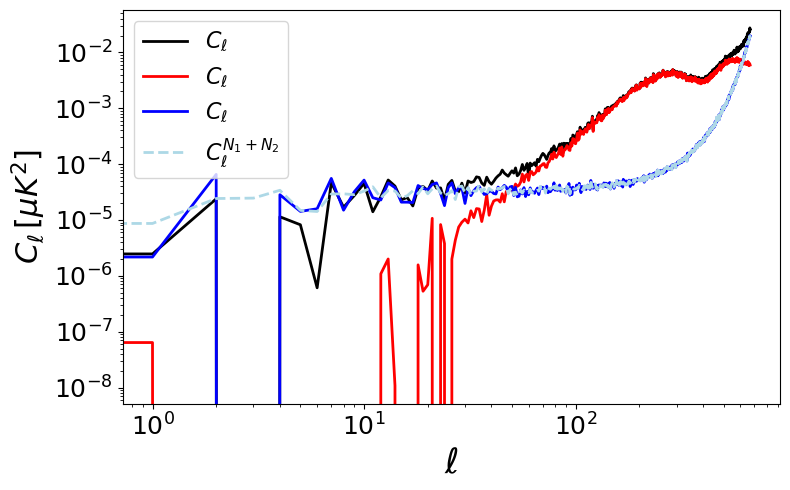

In [47]:
### covariance matrices = total - signal = diff map - initial tau signal 
#initial tau signal = tau^2 * Cl_CMB realization = diff map ideal case

fig = plt.figure(1, figsize=(8, 5))
#difference maps

plt.plot(ll[:lmax_cut0], Cls_map10_n-Cls_map10symm, color='k', ls='-', lw=2 , label='$C_\ell$') # noise+realistic beam
plt.plot(ll[:lmax_cut0], Cls_map10-Cls_map10symm, color='r', ls='-', lw=2 , label='$C_\ell$') # beam only
plt.plot(ll[:lmax_cut0], Cls_map10symm_n-Cls_map10symm, color='b', ls='-', lw=2 , label='$C_\ell$') # noise only

plt.plot(ll[:lmax_cut0], Cls_map_noise10_dec, color='lightblue', ls='--', lw=2 , label='$C_\ell^{N_1+N_2}$') # cov matrix for noise only case


#should coincide with Cls_diff_noise_only      

plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\ell$', fontsize=25)
plt.ylabel('$C_\ell\,[\mu K^2]$', fontsize=22)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=16, loc='upper left')
plt.tight_layout()

#plt.savefig("/home/evanetti/BEAMS/paper_figures/covariance.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [48]:
lmax_tau=250
lmin_tau=50


### here the tempate also contains systematics. 

# REALISTIC BEAM + NOISE
print('Realistic beam + noise')
covBN=Cls_map10_n-Cls_map10symm
tauBN, sigma_tauBN=tau_estimate(map0_n_dec, map1_n_dec, covBN, lmin_tau, lmax_tau)  

# REALISTIC BEAM, NOISELESS
print('\nRealistic beam (noiseless)')
covB=Cls_map10-Cls_map10symm
tauB, sigma_tauB=tau_estimate(map0_dec, map1_dec, covB,lmin_tau, lmax_tau)

# SYMMETRIC BEAM + NOISE
print('\nSymmetric beam + noise')
covN=Cls_map10symm_n-Cls_map10symm
tauN, sigma_tauN=tau_estimate(map0symm_n_dec, map1symm_n_dec, covN,lmin_tau,  lmax_tau)

### SYMMETRIC BEAM, NOISELESS
print('\nSymmetric beam (noiseless)')
tau0, sigma_tau0=tau_estimate(map0symm_dec, map1symm_dec, covB, lmin_tau, lmax_tau)

Realistic beam + noise
E[tau] = -0.001167 +- 0.000075  	 sigma distance: 2.229875	 tau interval: [-0.001242 - -0.001092]

Realistic beam (noiseless)
E[tau] = -0.001089 +- 0.000064  	 sigma distance: 1.383619	 tau interval: [-0.001154 - -0.001025]

Symmetric beam + noise
E[tau] = -0.001040 +- 0.000025  	 sigma distance: 1.595036	 tau interval: [-0.001065 - -0.001015]

Symmetric beam (noiseless)
E[tau] = -0.001000 +- 0.000064  	 sigma distance: 0.000000	 tau interval: [-0.001064 - -0.000936]


In [ ]:
#### other case with the right template: assuming to use CMB frequency independet anisotropies obtained with some component separation method. 

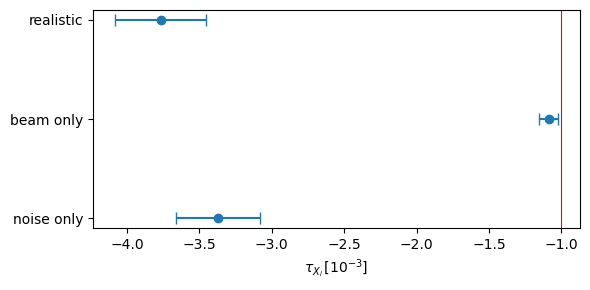

In [ ]:
cases = ["realistic", "beam only", "noise only"]
values = np.array([tauBN, tauB, tauN])*1e3
errors = np.array([sigma_tauBN, sigma_tauB, sigma_tauN])*1e3

y = np.arange(len(cases))

fig, ax = plt.subplots(figsize=(6,3))

ax.errorbar( values, y, xerr=errors,  fmt='o', capsize=4)

ax.set_yticks(y)
ax.set_yticklabels(cases)
ax.set_xlabel(r"$\tau_{X_i}\,[10^{-3}]$")
ax.axvline(-1, linewidth=0.8, color='red')

ax.invert_yaxis()  # optional: top-to-bottom reading
fig.tight_layout()

plt.show()

E[tau] = [0.00108913 0.00103999 0.00116685]
E[tau] - 0.001 = [8.91310729e-05 3.99888487e-05 1.66851428e-04]
sigma(tau)=  [6.44187995e-05 2.50708193e-05 7.48254468e-05]
sigma_distance = [1.38361897 1.59503558 2.22987547]


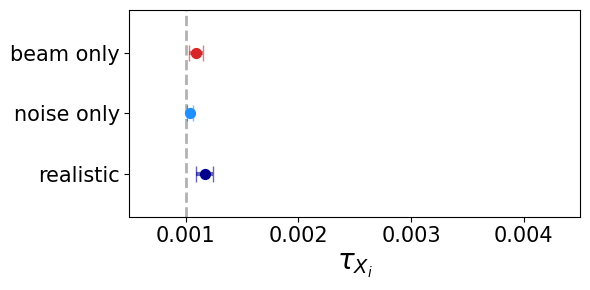

In [49]:

cases = ["beam only", "noise only", "realistic"]
values = np.array([-tauB, -tauN, -tauBN])
errors = np.array([sigma_tauB, sigma_tauN, sigma_tauBN])

print('E[tau] =', values)
print('E[tau] - 0.001 =', values - 1e-3)
print('sigma(tau)= ' ,errors)
print('sigma_distance =',(values-1e-3)/errors)


colors = ["tab:red", "dodgerblue", "darkblue"]

y = np.arange(len(cases))
y=y/10

fig, ax = plt.subplots(figsize=(6,3))

for i in range(len(cases)):
    ax.errorbar(
        values[i], y[i],
        xerr=errors[i],
        #fmt='none',
        color=colors[i],        # marker color
        ecolor=colors[i],       # error bar color
        elinewidth=3,           # thick error bars
        capsize=6,              # remove caps
        alpha=0.6               # semi-transparency
    )
    ax.scatter(
        values[i], y[i],
        color=colors[i],
        s=50,
        alpha=1.0,
        zorder=3
    )

ax.set_xticks([ 0.001, 0.002, 0.003, 0.004])
ax.tick_params(axis='x', labelsize=15)
ax.set_yticks(y)
ax.set_yticklabels(cases, fontsize=15)
ax.set_xlabel(r"$\tau_{X_i}$", fontsize=20)

ax.set_xlim(0.0005, 0.0045) 
ax.set_ylim(y[0]-0.07, y[-1]+0.07)

# Vertical reference line
ax.axvline(1e-3, color='black', linestyle='--', linewidth=2, alpha=0.3)

ax.invert_yaxis()
fig.tight_layout()

plt.savefig("/home/evanetti/BEAMS/paper_figures/matched_filtering.pdf", format="pdf", bbox_inches="tight")

plt.show()


noise introduces a bias // 
noiseless results are not biased

### Check cross - Cls

In [ ]:
## compute cross-scpectrum (neede for matched filtering)
Cls_cross_th = hp.anafast(mapdiff_th, map_cmb, lmax=lmax_cut0-1)
Cls_cross_real_n = hp.anafast(map10_n, map0_n_dec, lmax=lmax_cut0-1)
Cls_cross_real = hp.anafast(map10, map0_dec, lmax=lmax_cut0-1)
Cls_cross_symm_n = hp.anafast(map10symm_n, map0symm_n_dec, lmax=lmax_cut0-1)
Cls_cross_symm = hp.anafast(map10symm, map0symm_dec, lmax=lmax_cut0-1)

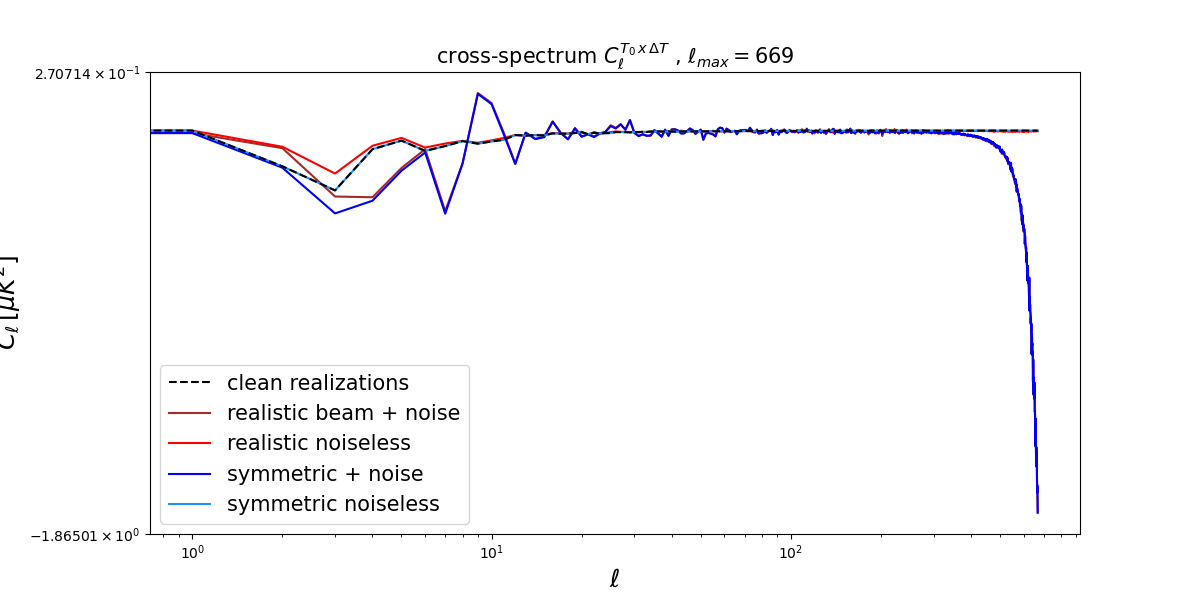

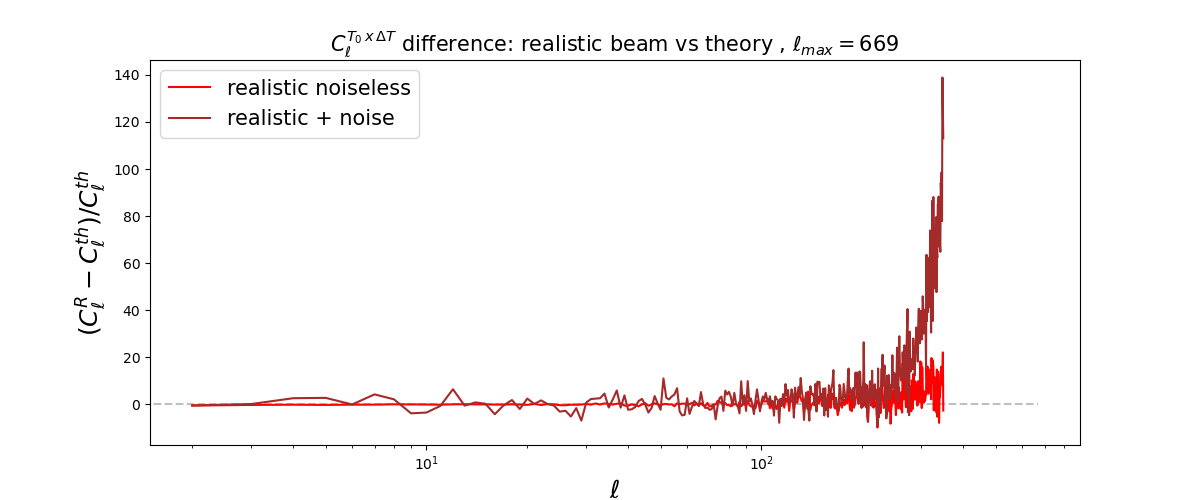

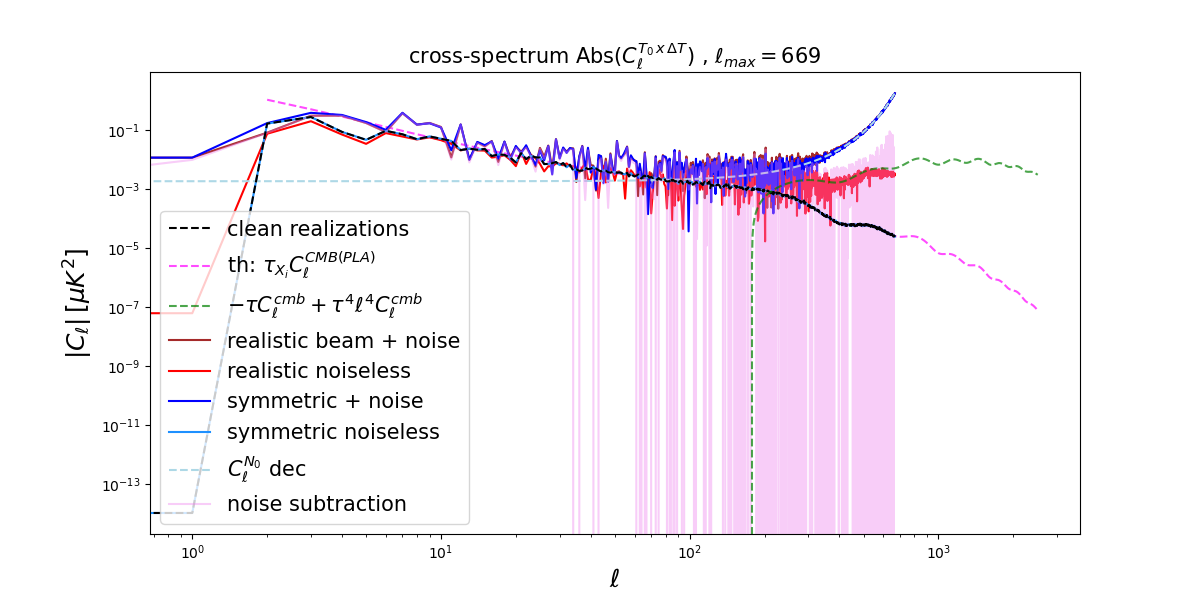

In [ ]:
# PLOT CROSS SPECTRA
plt.figure(figsize=(12,6))
plt.plot(ll_cut, Cls_cross_th, color='black', ls='--', label='clean realizations', zorder=3) 
plt.plot(ll_cut, Cls_cross_real_n, color='brown', ls='-',  label='realistic beam + noise') 
plt.plot(ll_cut, Cls_cross_real, color='red', ls='-',  label='realistic noiseless') 
plt.plot(ll_cut, Cls_cross_symm_n, color='blue', ls='-',  label='symmetric + noise') 
plt.plot(ll_cut, Cls_cross_symm, color='dodgerblue', ls='-',  label='symmetric noiseless') 

#plt.plot(ll_cut,  Cls_cross_real_n+Cls_noise0_dec_th, color='violet', ls='-',  label='noise subtraction') 


#plt.plot(ll_cut, Cls_map_noise0_dec, color='gray', ls='--',  label='30 GHz noise dec') 
#plt.plot(ll_cut, Cls_map_noise10_dec, color='gray', alpha=0.5, ls='-',  label='Diff. map noise dec') 


#plt.hlines(0., ll_cut[0], ll_cut[-1], color='gray', alpha=0.5, ls='--', zorder=0)

plt.xscale('log')
plt.yscale('symlog')
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
plt.title('cross-spectrum $C_\ell^{T_0\,x\,\Delta T}$ , $\ell_{max}=$'+str(lmax_cut0), fontsize=15)
plt.legend(fontsize=15)
plt.show()


#BEAM REASIDUALS: PLOT difference: realistic noiseless vs theory
cut2=350
plt.figure(figsize=(12,5))
plt.plot(ll_cut[2:cut2], (Cls_cross_real[2:cut2]-Cls_cross_th[2:cut2])/Cls_cross_th[2:cut2], color='red', ls='-', label='realistic noiseless', zorder=3) 
plt.plot(ll_cut[2:cut2], (Cls_cross_real_n[2:cut2]-Cls_cross_th[2:cut2])/Cls_cross_th[2:cut2], color='brown', ls='-', label='realistic + noise', zorder=3) 
plt.hlines(0., ll_cut[0], ll_cut[-1], color='gray', alpha=0.5, ls='--', zorder=0)

plt.xscale('log')
#plt.yscale('symlog')
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$(C_\ell^R-C_\ell^{th})/C_\ell^{th}$', fontsize=18)
plt.title('$C_\ell^{T_0\,x\,\Delta T}$ difference: realistic beam vs theory , $\ell_{max}=$'+str(lmax_cut0), fontsize=15)
plt.legend(fontsize=15)
plt.show()


### CHECK theoretical
plt.figure(figsize=(12,6))
plt.plot(ll_cut, np.abs(Cls_cross_th), color='black', ls='--', label='clean realizations', zorder=3) 
plt.plot(lPLA, tau_th*ClPLA,color='magenta', alpha=0.7,  ls='--', label=r'th: $\tau_{X_i}C_\ell^{CMB(PLA)}$')

plt.plot(lPLA, (-tau_th+tau_th**4*lPLA**4)*ClPLA ,color='green', alpha=0.7,  ls='--', label=r'$-\tau C_\ell^{cmb}+\tau^4\ell^4C_\ell^{cmb}$', zorder=10)


plt.plot(ll_cut,  np.abs(Cls_cross_real_n), color='brown', ls='-',  label='realistic beam + noise') 
plt.plot(ll_cut,  np.abs(Cls_cross_real), color='red', ls='-',  label='realistic noiseless') 
plt.plot(ll_cut,  np.abs(Cls_cross_symm_n), color='blue', ls='-',  label='symmetric + noise') 
plt.plot(ll_cut,  np.abs(Cls_cross_symm), color='dodgerblue', ls='-',  label='symmetric noiseless') 

plt.plot(ll_cut,  Cls_noise0_dec_th, color='lightblue', ls='--',  label='$C_\ell^{N_0}$ dec') 

plt.plot(ll_cut,  np.abs(Cls_cross_real_n)-Cls_noise0_dec_th, color='violet', alpha=0.4, ls='-',  label='noise subtraction') 



#plt.plot(ll_cut, Cls_map10, color='green', ls='-',  label='70-30 GHz') 


plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$|C_\ell|\,[\mu K^2]$', fontsize=18)
plt.title('cross-spectrum Abs($C_\ell^{T_0\,x\,\Delta T}$) , $\ell_{max}=$'+str(lmax_cut0), fontsize=15)
plt.legend(fontsize=15)
plt.show()



##plot Cls of Noise 1


### check that 


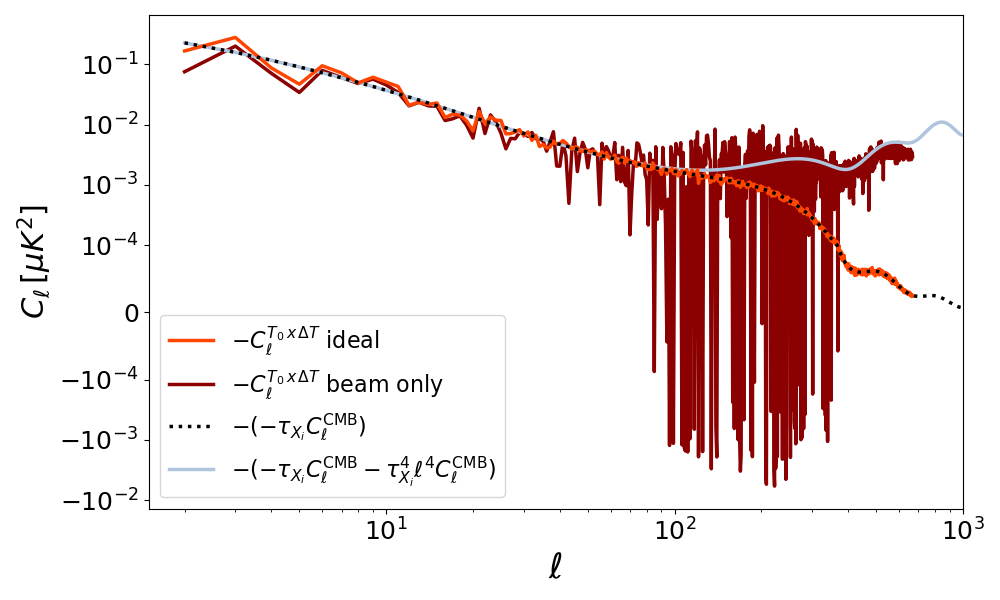

In [ ]:
### PLOT FOR PAPER
fig = plt.figure(figsize=(10, 6))

plt.plot(ll_cut[2:], -Cls_cross_symm[2:], color='orangered', ls='-', lw=2.5 , label=r'$-C_\ell^{T_0\,x\,\Delta T}$ ideal', zorder=9) # ideal 
plt.plot(ll_cut[2:], -Cls_cross_real[2:], color='darkred', ls='-', lw=2.5, label=r'$-C_\ell^{T_0\,x\,\Delta T}$ beam only') # realistic beam, noiseless
#plt.plot(ll_cut[2:], -Cls_cross_symm_n[2:], color='deepskyblue', ls='-', lw=2.5, label=r'$C_\ell^{T_0\,x\,\Delta T}$ noise only')  #noise only, summ beam
#plt.plot(ll_cut[2:], -Cls_cross_real_n[2:], color='darkblue', ls='--', lw=2.5,  label=r'$C_\ell^{T_0\,x\,\Delta T}$ realistic')  #realistic beam + noise
#plt.plot(ll_cut[2:], Cls_map10_n[2:]-Cls_noise10_dec_th[2:], color='navy', alpha=0.3, ls='-', lw=1.5, label=r'$C_\ell^{T_0\,x\,\Delta T}$  realistic - noise ', zorder=0)  # realistic beam + noise, with noise model subtraction

#attempt of modeling beam residuals
#plt.plot(ll_cut,  (tau_th**4)*(ll_cut**4)*Cls_map_cmb[:lmax_cut0], color='blue', ls=':',  label=r'$\tau^4\ell^4 C_l^{cmb}$')  ### ATTEMPT of beam res. modeling
plt.plot(lPLA, tau_l[2:int(lPLA[-1]+1)]*ClPLA,color='black', ls=':', lw=2.5, label=r'$-(-\tau_{X_i} C_\ell^{\rm{CMB}})$', zorder=10)  #theoretical from PLA

fit_attempt2=tau_l[2:int(lPLA[-1]+1)]*ClPLA  +  lPLA**4*tau_l[2:int(lPLA[-1]+1)]**4*ClPLA
plt.plot(lPLA, fit_attempt2 ,color='lightsteelblue', alpha=1., ls='-', zorder=8, lw=2.5, label=r'$-(-\tau_{X_i} C_\ell^{\rm{CMB}} -\tau_{X_i}^4 \ell^4 C_\ell^{\rm{CMB}})$')  #theoretical from PLA
'''
fit_attempt3=tau_l[2:int(lPLA[-1]+1)]*ClPLA  +  lPLA**4.5*tau_l[2:int(lPLA[-1]+1)]**4.5*ClPLA
plt.plot(lPLA, fit_attempt3 ,color='tab:purple', alpha=1., ls='-', zorder=7, lw=2.5, label=r'$-(-\tau_{X_i} C_\ell^{\rm{CMB}} -\tau_{X_i}^4 \ell^4 C_\ell^{\rm{CMB}})$')  #theoretical from PLA
'''

#plt.ylim(1e-9, 10)
plt.xlim(1.5, 1e3)
plt.xscale('log')

plt.yscale('symlog', linthresh=1e-4)
plt.xlabel('$\ell$', fontsize=25)
plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=22)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=16, loc='lower left')
plt.tight_layout()

plt.savefig("/home/evanetti/BEAMS/paper_figures/Clscross.pdf", format="pdf", bbox_inches="tight")

plt.show()

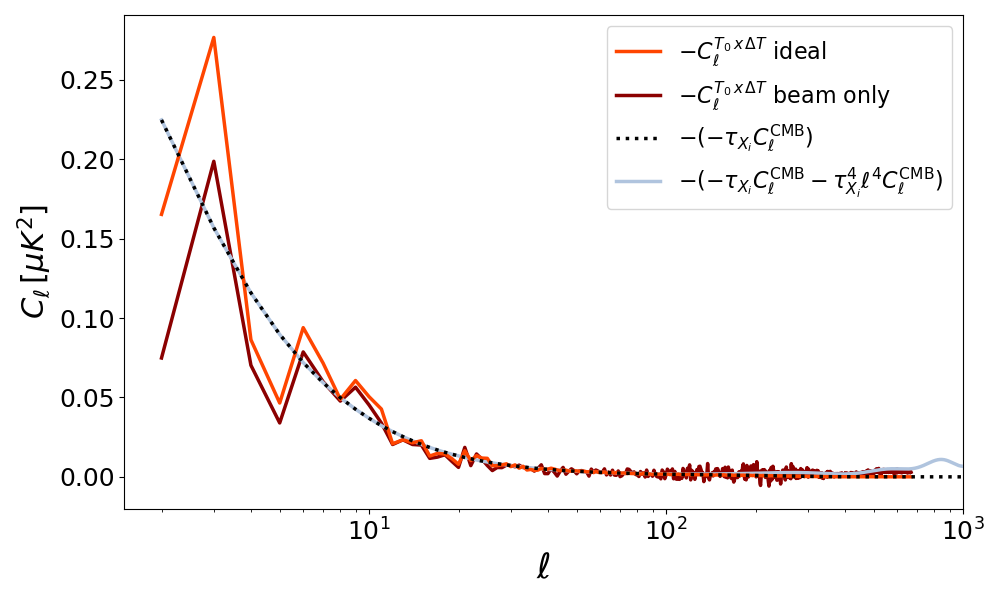

In [ ]:
### PLOT FOR PAPER
fig = plt.figure(figsize=(10, 6))
plt.plot(ll_cut[2:], -Cls_cross_symm[2:], color='orangered', ls='-', lw=2.5 , label=r'$-C_\ell^{T_0\,x\,\Delta T}$ ideal', zorder=9) # ideal 
plt.plot(ll_cut[2:], -Cls_cross_real[2:], color='darkred', ls='-', lw=2.5, label=r'$-C_\ell^{T_0\,x\,\Delta T}$ beam only') # realistic beam, noiseless
#plt.plot(ll_cut[2:], -Cls_cross_symm_n[2:], color='deepskyblue', ls='-', lw=2.5, label=r'$C_\ell^{T_0\,x\,\Delta T}$ noise only')  #noise only, summ beam
#plt.plot(ll_cut[2:], -Cls_cross_real_n[2:], color='darkblue', ls='--', lw=2.5,  label=r'$C_\ell^{T_0\,x\,\Delta T}$ realistic')  #realistic beam + noise


#attempt of modeling beam residuals
#plt.plot(ll_cut,  (tau_th**4)*(ll_cut**4)*Cls_map_cmb[:lmax_cut0], color='blue', ls=':',  label=r'$\tau^4\ell^4 C_l^{cmb}$')  ### ATTEMPT of beam res. modeling
plt.plot(lPLA, tau_l[2:int(lPLA[-1]+1)]*ClPLA,color='black', ls=':', lw=2.5, label=r'$-(-\tau_{X_i} C_\ell^{\rm{CMB}})$', zorder=10)  #theoretical from PLA

fit_attempt2=tau_l[2:int(lPLA[-1]+1)]*ClPLA  +  lPLA**4*tau_l[2:int(lPLA[-1]+1)]**4*ClPLA
plt.plot(lPLA, fit_attempt2 ,color='lightsteelblue', alpha=1., ls='-', zorder=8, lw=2.5, label=r'$-(-\tau_{X_i} C_\ell^{\rm{CMB}} -\tau_{X_i}^4 \ell^4 C_\ell^{\rm{CMB}})$')  #theoretical from PLA
'''
fit_attempt3=tau_l[2:int(lPLA[-1]+1)]*ClPLA  +  lPLA**4.5*tau_l[2:int(lPLA[-1]+1)]**4.5*ClPLA
plt.plot(lPLA, fit_attempt3 ,color='tab:purple', alpha=1., ls='-', zorder=7, lw=2.5, label=r'$-(-\tau_{X_i} C_\ell^{\rm{CMB}} -\tau_{X_i}^4 \ell^4 C_\ell^{\rm{CMB}})$')  #theoretical from PLA
'''

#plt.ylim(1e-9, 10)
plt.xlim(1.5, 1e3)
plt.xscale('log')
plt.xlabel('$\ell$', fontsize=25)
plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=22)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=16, loc='upper right')
plt.tight_layout()
plt.show()

Cross theoretical cmb map x realistic noiseless difference map: 

$C_l^{T_0\times\delta T}=\langle a_{lm}^{*0}\delta a_{lm}\rangle=
\langle a_{lm}^{cmb*}[(-\tau+\delta \epsilon_{lm})a_{lm}^{cmb}]\rangle = -\tau C_l^{cmb} +\langle \delta\epsilon_{lm}\rangle C_l^{cmb}$ 


Cross deconvolved cmb map x realistic noiseless difference map: 

$C_l^{T_0\times\delta T}=\langle a_{lm}^{*0}\delta a_{lm}\rangle=
\langle [(1+\epsilon_{lm}^0)a_{lm}^{cmb}]^*[(-\tau+\delta\epsilon_{lm})a_{lm}^{cmb}]\rangle = -\tau C_l^{cmb} +\langle\delta\epsilon_{lm}\rangle C_l^{cmb}-\tau\langle\epsilon_{lm}^0\rangle C_l^{cmb} +\langle\epsilon_{lm}^0\delta\epsilon_{lm}\rangle C_l^{cmb}$ 

--> dominant term: $\langle\epsilon_{lm}^0\delta\epsilon_{lm}\rangle C_l^{cmb}= (\langle  \epsilon_{lm}^0 \epsilon_{lm}^1\rangle - |\epsilon_{lm}^0|^2 ) C_l^{cmb} \sim - \tau^4 \ell^4 C_l^{cmb} $


Noisy case:

$C_l^{T_0\times\delta T}=\langle a_{lm}^{*0}\delta a_{lm}\rangle=\langle [a_{lm}^{cmb}+N_1]^*[(-\tau+\delta\epsilon_{lm})a_{lm}^{cmb}+N_2-N_1]\rangle = -\tau C_l^{cmb} +\langle\delta\epsilon_{lm}\rangle C_l^{cmb}-C_\ell^{N_1}$ 

+ negliglible terms: $\langle N_2 a_{lm}^{cmb}\rangle+ \langle N_1a_{lm}^{cmb}\rangle-\tau\langle N_1a_{lm}^{cmb}\rangle+ \langle N_1N_2\rangle$        !! one of these seems to not be negliglible!!  Try all of these separately 

!! Include deconvolution in the calculation !!

- Symmetric beam, noiseless: $C_l^{T_0\times\delta T}=-\tau C_l^{cmb}$
- Symmetrci beam + noise: $C_l^{T_0\times\delta T}=-\tau C_l^{cmb}-C_\ell^{N_1}$
- Realistic beam, noiseless: $C_l^{T_0\times\delta T}=(-\tau +\langle\delta\epsilon_{lm}\rangle) C_l^{cmb}$
- Realistic beam + noise: $C_l^{T_0\times\delta T}=(-\tau +\langle\delta\epsilon_{lm}\rangle) C_l^{cmb}-C_\ell^{N_1}$



ERROR: ALSO THE 1ST MAP HAS BEAM RESIDUALS + deconvolution aplification is not considered 
- compare beam residuals before and after deconvolution
- compute beam residual difference from plot above 
- do the same as plot below but with theoretical CMB map ---> isolate actual delta epsilon

Isolate $\langle \delta \epsilon_{lm}\rangle$ from Cross Cls of relistic noiseless case: $\langle\delta\epsilon_{lm}\rangle =\tau+C_l^{T_0\times\delta T}/C_l^{cmb}$

1) why are the cross Cls beam residuals more scattered than in the difference map

2) residual behaviour on large scales 

3) noise subtraction: compute the average every 10 ells and see if it follows the right expected curve

4) see if the beam residuals model can be modified to include the beam residuals

5) rederive matched filtering eq. for this case + understand beam residuals better 

In [ ]:
## compute cross-scpectrum (neede for matched filtering)
Cls_cross_th_ = hp.anafast(mapdiff_th, map_cmb, lmax=lmax_cut0-1)
Cls_cross_real_ = hp.anafast(mapdiff_th, map0_dec, lmax=lmax_cut0-1)

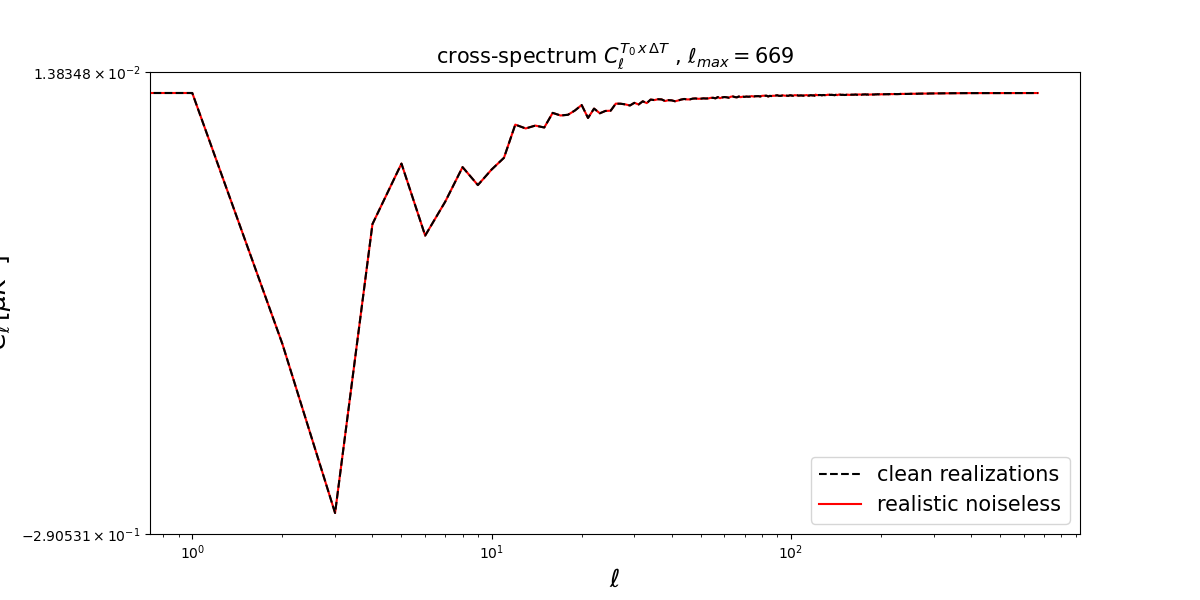

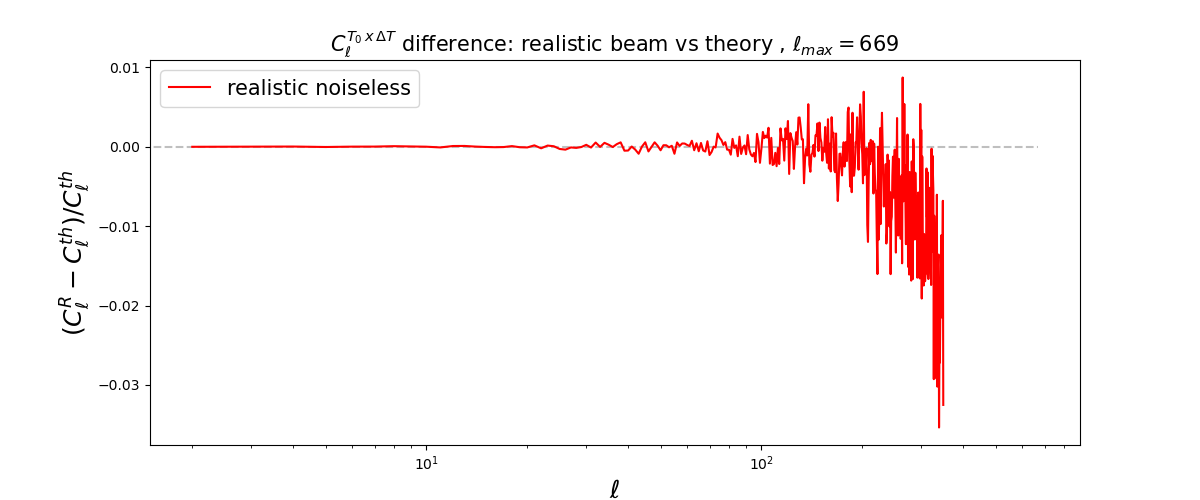

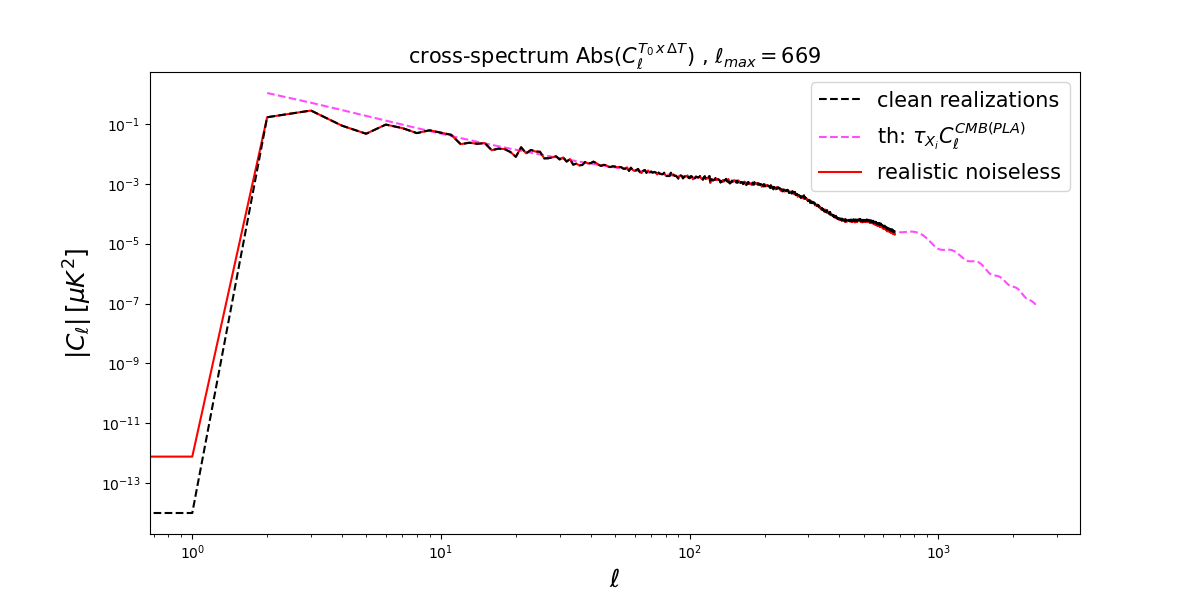

In [ ]:
# PLOT CROSS SPECTRA
plt.figure(figsize=(12,6))
plt.plot(ll_cut, Cls_cross_th, color='black', ls='--', label='clean realizations', zorder=3) 
plt.plot(ll_cut, Cls_cross_real_, color='red', ls='-',  label='realistic noiseless') 


#plt.plot(ll_cut,  Cls_cross_real_n+Cls_noise0_dec_th, color='violet', ls='-',  label='noise subtraction') 


#plt.plot(ll_cut, Cls_map_noise0_dec, color='gray', ls='--',  label='30 GHz noise dec') 
#plt.plot(ll_cut, Cls_map_noise10_dec, color='gray', alpha=0.5, ls='-',  label='Diff. map noise dec') 


#plt.hlines(0., ll_cut[0], ll_cut[-1], color='gray', alpha=0.5, ls='--', zorder=0)

plt.xscale('log')
plt.yscale('symlog')
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
plt.title('cross-spectrum $C_\ell^{T_0\,x\,\Delta T}$ , $\ell_{max}=$'+str(lmax_cut0), fontsize=15)
plt.legend(fontsize=15)
plt.show()


#BEAM REASIDUALS: PLOT difference: realistic noiseless vs theory
cut2=350
plt.figure(figsize=(12,5))
plt.plot(ll_cut[2:cut2], (Cls_cross_real_[2:cut2]-Cls_cross_th[2:cut2])/Cls_cross_th[2:cut2], color='red', ls='-', label='realistic noiseless', zorder=3) 
plt.hlines(0., ll_cut[0], ll_cut[-1], color='gray', alpha=0.5, ls='--', zorder=0)

plt.xscale('log')
#plt.yscale('symlog')
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$(C_\ell^R-C_\ell^{th})/C_\ell^{th}$', fontsize=18)
plt.title('$C_\ell^{T_0\,x\,\Delta T}$ difference: realistic beam vs theory , $\ell_{max}=$'+str(lmax_cut0), fontsize=15)
plt.legend(fontsize=15)
plt.show()


### CHECK theoretical
plt.figure(figsize=(12,6))
plt.plot(ll_cut, np.abs(Cls_cross_th), color='black', ls='--', label='clean realizations', zorder=3) 
plt.plot(lPLA, tau_th*ClPLA,color='magenta', alpha=0.7,  ls='--', label=r'th: $\tau_{X_i}C_\ell^{CMB(PLA)}$')

plt.plot(ll_cut,  np.abs(Cls_cross_real_), color='red', ls='-',  label='realistic noiseless') 

plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$|C_\ell|\,[\mu K^2]$', fontsize=18)
plt.title('cross-spectrum Abs($C_\ell^{T_0\,x\,\Delta T}$) , $\ell_{max}=$'+str(lmax_cut0), fontsize=15)
plt.legend(fontsize=15)
plt.show()


## BEAM residuals

In [ ]:
## isolated beam residuals: 
Cls_T0xdiff_th=hp.anafast(mapdiff_th, map0_dec, lmax=lmax_cut0-1)
Cls_T1xdiff_th=hp.anafast(mapdiff_th, map1_dec, lmax=lmax_cut0-1)

Cls_T0xT0_th=hp.anafast(map_cmb, map0_dec, lmax=lmax_cut0-1)
Cls_T1xT0_th=hp.anafast(map_cmb, map1_dec, lmax=lmax_cut0-1)


In [ ]:
## 30 GHz beam residuals averaged
#beam_res0=Cls_T0xdiff_th[2:]/(-tau_l[2:lmax_cut0]*Cls_map_cmb[2:lmax_cut0])-1 #from diff map
beam_res0=Cls_T0xT0_th[2:]/Cls_map_cmb[2:lmax_cut0]-1 #from single map

#30 GHz beam residuals averaged
#beam_res1=(Cls_T1xdiff_th[2:]/Cls_map_cmb[2:lmax_cut0]+tau_l[2:lmax_cut0]-tau_l[2:lmax_cut0]**2)/(-tau_l[2:lmax_cut0])
beam_res1=Cls_T1xT0_th[2:]/Cls_map_cmb[2:lmax_cut0]-1+tau_l[2:lmax_cut0]


#squared residuals: 
beam_res0_sq=Cls_map0_dec/Cls_map_cmb[:lmax_cut0]-1
beam_res1_sq=Cls_map0_dec/Cls_map_cmb[:lmax_cut0]-1-tau_l[:lmax_cut0]**2+2*tau_l[:lmax_cut0]

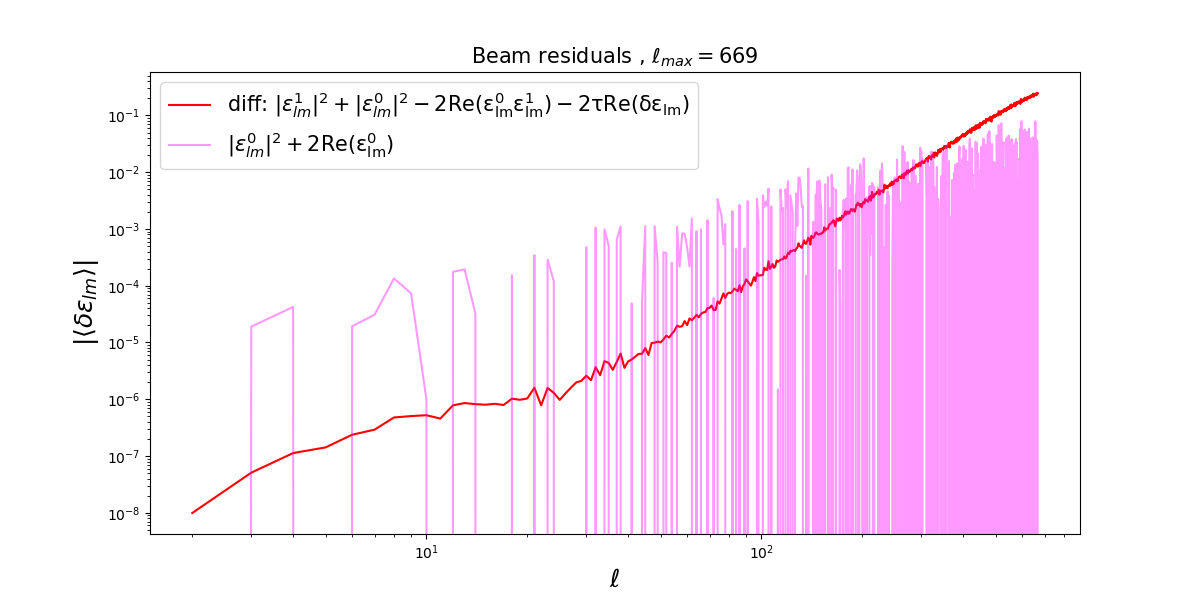

In [ ]:
plt.figure(figsize=(12,6))
#plt.plot(ll_cut, np.abs(Cls_cross_th), color='black', ls='--', label='clean realizations', zorder=3) 
#plt.plot(lPLA, tau_th*ClPLA,color='magenta', alpha=0.7,  ls='--', label=r'th: $\tau_{X_i}C_\ell^{CMB(PLA)}$')

beam_res_=tau_l[:lmax_cut0]+Cls_cross_real_/Cls_map_cmb[:lmax_cut0] #cross Cls: ideal T0 x realistic diff
beam_res=tau_l[:lmax_cut0]+Cls_cross_real/Cls_map_cmb[:lmax_cut0] #cross Cls: realistic T0 x realistic diff map
beam_res_diff=Cls_map10[2:]/Cls_map_cmb[2:lmax_cut0]-tau_l[2:lmax_cut0]**2 #realistic diff map

#plt.plot(ll_cut[2:], beam_res_[2:] , color='limegreen', ls='-',  label=r'cross_th: $\langle\epsilon_{lm}^1\rangle - \langle\epsilon_{lm}^0\rangle = \langle\delta\epsilon_{lm}\rangle $') 
#plt.plot(ll_cut[2:], -beam_res[2:]  , color='blue', ls='-', zorder=0,  label=r'cross: $-[- |\epsilon_{lm}^0|^2 + \langle  \epsilon_{lm}^0 \epsilon_{lm}^1\rangle + \langle\epsilon_{lm}^1\rangle - (1-\tau)\langle\epsilon_{lm}^0\rangle ]$') 

plt.plot(ll_cut[2:], Cls_map10[2:]/Cls_map_cmb[2:lmax_cut0], color='red', ls='-',  label=r'diff: $ |\epsilon_{lm}^1|^2 + |\epsilon_{lm}^0|^2 - 2\rm{Re}(\epsilon_{lm}^0\epsilon_{lm}^1) - 2\tau\rm{Re}(\delta\epsilon_{lm})$') 


#plt.plot(ll_cut[2:], beam_res1  , color='limegreen', ls='-',  label=r'$\langle\epsilon_{lm}^1\rangle$', zorder=6) 
#plt.plot(ll_cut[2:], - beam_res0  , color='orange', alpha=0.4, ls='-',  label=r'$- \langle\epsilon_{lm}^0\rangle$') 


#plt.plot(ll_cut[2:], beam_res1_sq[2:]  , color='magenta', ls='-',  label=r'$|\epsilon_{lm}^1|^2+2(1-\tau)\rm{Re}(\epsilon_{lm}^1)$') 
plt.plot(ll_cut[2:], beam_res0_sq[2:]  , color='magenta', alpha=0.4, ls='-',  label=r'$|\epsilon_{lm}^0|^2+2\rm{Re}(\epsilon_{lm}^0)$') 


#plt.plot(ll_cut[2:], (tau_th)**4*(ll_cut[2:])**4  , color='black', ls='--',  label=r'$\tau^4\ell^4 $') 
#plt.plot(ll_cut[2:], (tau_th)**5*(ll_cut[2:])**4  , color='gray', ls='--',  label=r'$\tau^5\ell^4 $') 


#plt.plot(ll_cut[2:], Cls_eps0[2:] , color='blue', ls='-', label='$|\epsilon_{lm}^0|^2$') 
#plt.plot(ll_cut[2:],Cls_eps1[2:] , color='green', ls='-', label='$|\epsilon_{lm}^1|^2$')
#plt.plot(ll_cut[2:],Cls_eps1[2:]+Cls_eps0[2:] , color='orange', ls='--', label='$|\epsilon_{lm}^0|^2+|\epsilon_{lm}^1|^2$')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$|\langle\delta\epsilon_{lm}\rangle|$', fontsize=18)
plt.title('Beam residuals , $\ell_{max}=$'+str(lmax_cut0), fontsize=15)
plt.legend(fontsize=15)
plt.show()


Cross theoretical cmb map x realistic noiseless difference map: 

$C_l^{T_0\times\delta T}=\langle a_{lm}^{*0}\delta a_{lm}\rangle=
\langle a_{lm}^{cmb*}[(-\tau+\delta \epsilon_{lm})a_{lm}^{cmb}]\rangle = -\tau C_l^{cmb} +\langle \delta\epsilon_{lm}\rangle C_l^{cmb}$ 

# Noise subtraction 

Noise is amplified on small scales by the deconvolution: 
- noise of the deconvolved map: $C_\ell^{(N_1)\rm{dec}}=C_\ell^{N_1}/C_\ell^1$ (for both maps)
- noise of the difference map: $C_\ell^{(N_1+N_2)\rm{dec}}=C_\ell^{N_1}/C_\ell^1+C_\ell^{N_2}/b_\ell^2$


Strategies to remove noise: 
0) WIENER FILTER?? 
1) subtract $C_\ell^{(N_1+N_2)\rm{dec}}$ from the difference map 1) use noise estimate  2) use actual noise Cls  --> similar results: coincides with noiseless realistic case so I think the noise is subtracted correctly, even with the fitted model (neglects noise x signal correlation) 
 
2) subtract noise estimate from each deconvolved map, then take the difference $C_\ell^{(N_1)\rm{dec}}=C_\ell^{N_1}/b_\ell^1$
3) same as 1,2 but fit the noise with a constant and use that
4) subtract noise Cls before deconvolution (I don't think this will work)

Real case: 
- could subtract noise at the level of $C_\ell$s, like here
- could also subtract a noise map in advance. Then only noise residuals would get amolified 


DOUBT: how to model the noise Cls that go in the match filter if I subtract the noise? They should account for the noise residuals

PROBLEM?? why are the subtraction Cls not going to zero on large scales? They should


try: compute difference map from cleaned maps and then take the Cls

checked that $C_\ell^N/b_\ell$ is exactly the same as $C_\ell$ from the deconvolved noise map



data map: dm --> $C_\ell^m$ = data Cls

foreground template map: dS --> $C_\ell^S$ = foreground Cls

$\alpha=\frac{1}{f_{\rm{sky}}}\frac{\sum_\ell^{\ell_{\rm{max}}} (2\ell+1)C_\ell^{m\times S} / C_\ell^m }{\sum_\ell^{\ell_{\rm{max}}} C_\ell^s/C_\ell^m}$ 

### Code execution time in slurm

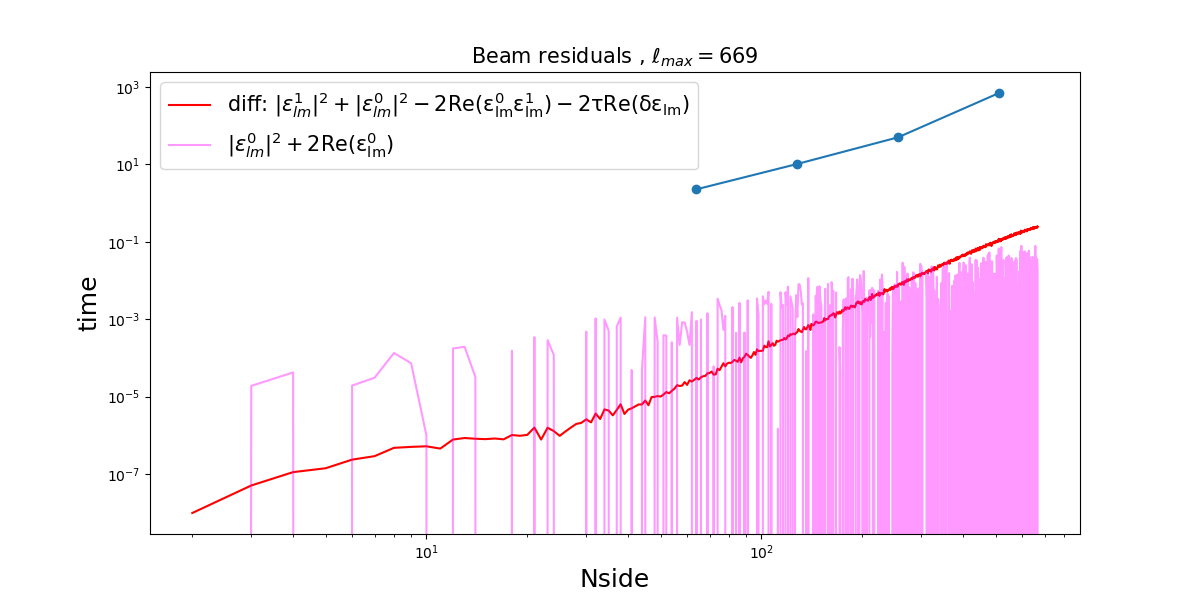

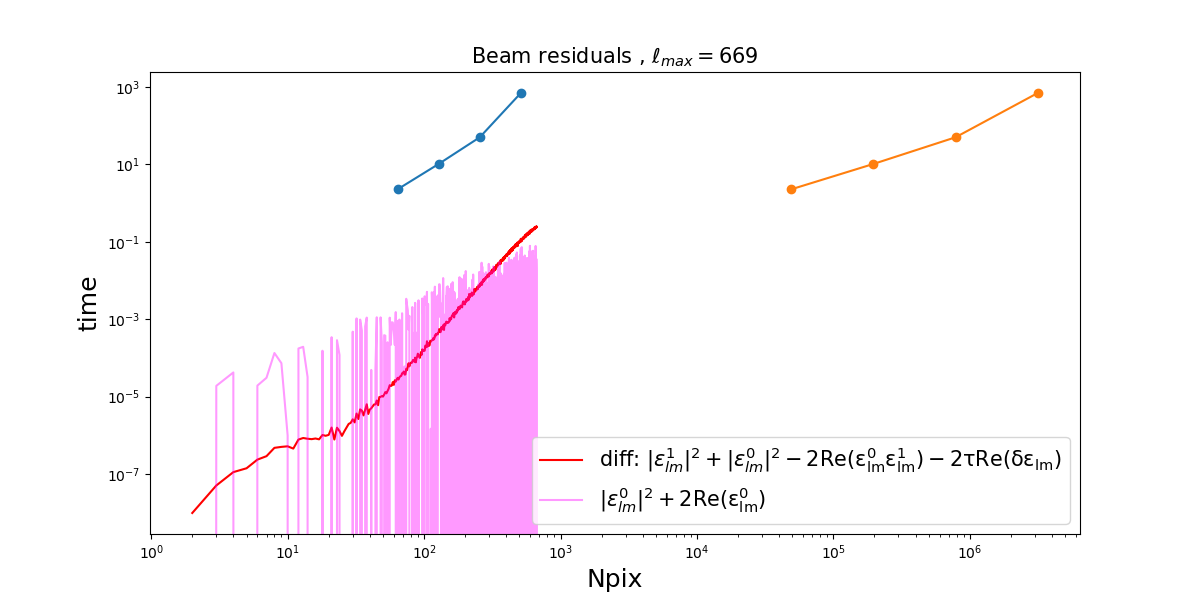

In [ ]:
## time for convolution loop - Ncores=10
#Nside=64   npix=49152      t=2.275 s       iteration time=4.628e-05    conv_test.o128551
#Nside=128  npix=196608     t=10.277 s      iteration time=5.227e-05    conv_test.o128421
#Nside=256  npix=786432     t=50.188 s      iteration time=6.381e-05     conv_test.o128423
#Nside=512  npix=12582912   t=      iteration time=

nside_run=np.array([64, 128, 256, 512, 1024])
npix=12*nside_run**2
time=np.array([2.275, 10.277, 50.188, 698.540, 0.0])

plt.plot(nside_run[:-1], time[:-1], marker='o')
plt.xlabel('Nside')
plt.ylabel('time')
plt.xscale('log')
plt.yscale('log')
plt.show()


plt.plot(npix[:-1], time[:-1], marker='o')
plt.xlabel('Npix')
plt.ylabel('time')
plt.xscale('log')
plt.yscale('log')
plt.show()